# Research questions — role, tier and reasoning effort in an LLM fault-localization chain

Agent4LR ranks a bug's top-20 candidate methods with a three-slot chain:
**planner → tool-caller → finisher**. Each slot can run a different model tier and
reasoning effort, so the same pipeline spans configurations that differ by orders of
magnitude in price. This notebook asks which of those choices actually buy accuracy.

The grid is the 39-configuration *swap-expanded* cut described in
[`swap-expanded.md`](swap-expanded.md): three background tiers `mᵢ`, three swapped roles
`X ∈ {P, T, F}`, five swept variants `m ∈ {M1R1, M2R1, M2R2, M2R3, M3R1}`, with the three
homogeneous anchors shared across roles. Both benchmarks are read from the committed
evaluation tables in `evaluation/` — D4J on the bug panel where all 39 configurations
produced a ranking, and BugsInPy likewise.

**Notation.** `U(mᵢ)` is the uniform configuration at tier `i`; `X(mᵢ, m)` is the same
background with role `X` swapped to variant `m`; `MAR` is the mean average rank of the
faulty method (lower is better) and `Cost` the mean USD per bug.

The six questions:

1. Which role affects accuracy the most?
2. Which role affects cost the most?
3. Does more reasoning effort improve accuracy?
4. Does a higher model tier improve accuracy?
5. What do effort and tier upgrades cost?
6. Does mixing models beat a uniform chain on the cost/accuracy frontier?

## 0. Setup

In [1]:
import sys
from pathlib import Path

import pandas as pd

# Resolve the repo root from wherever the kernel was started, then import the
# frame builders that read the committed evaluation/ tables.
REPO_ROOT = Path.cwd().resolve()
while not (REPO_ROOT / "evaluation").is_dir() and REPO_ROOT != REPO_ROOT.parent:
    REPO_ROOT = REPO_ROOT.parent
sys.path.insert(0, str(REPO_ROOT / "analysis"))

from frames import build_frames, eval_csv  # noqa: E402

print(f"repo: {REPO_ROOT}")

repo: /home/itai/git/CE_LLM_FL


In [2]:
# --- Definitions ------------------------------------------------------------
MODELS = ["M1R1", "M2R1", "M2R2", "M2R3", "M3R1"]  # swept variants m, cheap → expensive
PHASES = ["P", "T", "F"]
TIERS = [1, 2, 3]


def m_(i: int) -> str:
    """m_i — the minimal-reasoning agent of size rank i (M<i>R1)."""
    return f"M{i}R1"


def Flex(m: str, m2: str, m3: str) -> str:
    """Flex(m, m', m'') — Planner-ToolCaller-Finisher config string."""
    return f"{m}-{m2}-{m3}"


def U(m: str) -> str:
    """U(m) — uniform config."""
    return Flex(m, m, m)


def P(m: str, mp: str) -> str:
    """P(m, m') — planner swapped to m' on an m background."""
    return Flex(mp, m, m)


def T(m: str, mp: str) -> str:
    """T(m, m') — tool-caller swapped to m' on an m background."""
    return Flex(m, mp, m)


def F(m: str, mp: str) -> str:
    """F(m, m') — finisher swapped to m' on an m background."""
    return Flex(m, m, mp)


PHASE_FN = {"P": P, "T": T, "F": F}

# Metric helpers read the module-level binding set by use_dataset() — call it
# with a benchmark's summary_by_config frame before using MAR/Cost & friends.
_mar: pd.Series
_cost: pd.Series
_COST_MIN = _COST_MAX = float("nan")


def use_dataset(summary_df: pd.DataFrame) -> None:
    """Bind MAR/Cost (and the cost-normalization range) to a summary frame."""
    global _mar, _cost, _COST_MIN, _COST_MAX
    _mar = summary_df.set_index("Config")["MAR"]
    _cost = summary_df.set_index("Config")["MeanCostUSD"]
    _COST_MIN, _COST_MAX = _cost.min(), _cost.max()


def MAR(config: str) -> float:
    return float(_mar[config])


def Cost(config: str) -> float:
    """Mean cost per bug (USD)."""
    return float(_cost[config])


def _sweep(metric, X: str, i: int) -> list[float]:
    """metric(X(m_i, m)) for each swept variant m, in MODELS order."""
    return [metric(PHASE_FN[X](m_(i), m)) for m in MODELS]


def MinMAR(X: str, i: int) -> float:
    return min(_sweep(MAR, X, i))


def MaxMAR(X: str, i: int) -> float:
    return max(_sweep(MAR, X, i))


def _norm_cost(v: float) -> float:
    """Min-max normalize a cost into 0~1 over the 39-config grid's Cost range."""
    return (v - _COST_MIN) / (_COST_MAX - _COST_MIN)


def MinCost(X: str, i: int, norm: bool = False) -> float:
    v = min(_sweep(Cost, X, i))
    return _norm_cost(v) if norm else v


def MaxCost(X: str, i: int, norm: bool = False) -> float:
    v = max(_sweep(Cost, X, i))
    return _norm_cost(v) if norm else v


def ArgMinMAR(X: str, i: int) -> str:
    return min(MODELS, key=lambda m: MAR(PHASE_FN[X](m_(i), m)))


def ArgMaxMAR(X: str, i: int) -> str:
    return max(MODELS, key=lambda m: MAR(PHASE_FN[X](m_(i), m)))


def ArgMinCost(X: str, i: int) -> str:
    return min(MODELS, key=lambda m: Cost(PHASE_FN[X](m_(i), m)))


def ArgMaxCost(X: str, i: int) -> str:
    return max(MODELS, key=lambda m: Cost(PHASE_FN[X](m_(i), m)))


def UMinMAR(X: str, i: int) -> float:
    return MAR(U(m_(i))) - MinMAR(X, i)


def UMinCost(X: str, i: int, norm: bool = False) -> float:
    u = Cost(U(m_(i)))
    return (_norm_cost(u) if norm else u) - MinCost(X, i, norm)


def MaxMinMAR(X: str, i: int) -> float:
    return MaxMAR(X, i) - MinMAR(X, i)


def MaxMinCost(X: str, i: int, norm: bool = False) -> float:
    return MaxCost(X, i, norm) - MinCost(X, i, norm)


def short(m: str) -> str:
    """Label form of an agent: 'm2' for M2R1, otherwise the raw string (e.g. 'M2R2')."""
    return f"m{m[1]}" if m.endswith("R1") else m


def point_label(X: str, i: int, m: str) -> str:
    """Scatter-point label: 'U(m2)' for the uniform, else e.g. 'P(m1,M2R2)'."""
    return f"U(m{i})" if m == m_(i) else f"{X}(m{i},{short(m)})"


def check_grid(summary_df: pd.DataFrame) -> None:
    """Sanity: the notation reproduces exactly the 39-config grid."""
    grid = {PHASE_FN[X](m_(i), m) for X in PHASES for i in TIERS for m in MODELS}
    assert grid == set(summary_df["Config"]), "grid/notation mismatch"
    print(f"{len(grid)} unique configs from {3 * 3 * 5} (X, i, m) combinations — matches the sweep")

In [3]:
import plotly.graph_objects as go


def sortable_table(df, sort_by=None, ascending=False, title=None):
    """Render a DataFrame as a plotly Table with a sort dropdown.

    go.Table has no native click-to-sort, so the dropdown's buttons swap in
    pre-sorted cell values (one ascending / descending entry per column).
    ``sort_by``/``ascending`` set the initial ordering; the DataFrame itself
    is left untouched.
    """
    cols = list(df.columns)

    def _fmt(c):
        if pd.api.types.is_float_dtype(df[c]):
            return ".6f" if df[c].abs().max() < 0.1 else ".3f"
        return None

    def _values(d):
        return [d[c].tolist() for c in cols]

    df0 = df.sort_values(sort_by, ascending=ascending) if sort_by else df
    fig = go.Figure(
        go.Table(
            header=dict(
                values=[f"<b>{c}</b>" for c in cols],
                fill_color="#e1e0d9",
                font=dict(color="#0b0b0b", size=12),
                align="left",
            ),
            cells=dict(
                values=_values(df0),
                format=[_fmt(c) for c in cols],
                fill_color="#fcfcfb",
                font=dict(color="#52514e", size=11),
                align="left",
                height=22,
            ),
        )
    )
    buttons = [
        dict(
            label=f"{c} {arrow}",
            method="restyle",
            args=[{"cells.values": [_values(df.sort_values(c, ascending=asc))]}],
        )
        for c in cols
        for asc, arrow in ((True, "▲"), (False, "▼"))
    ]
    initial = f"{sort_by} {'▲' if ascending else '▼'}" if sort_by else f"{cols[0]} ▲"
    fig.update_layout(
        updatemenus=[
            dict(
                buttons=buttons,
                active=[b["label"] for b in buttons].index(initial) if sort_by else -1,
                direction="down",
                x=1.0,
                xanchor="right",
                y=1.0,
                yanchor="bottom",
            )
        ],
        annotations=[
            dict(
                text="sort:",
                showarrow=False,
                x=1.0,
                xanchor="right",
                xshift=-160,
                y=1.02,
                yanchor="bottom",
                yref="paper",
                font=dict(color="#898781", size=12),
            )
        ],
        title=dict(text=title, font=dict(color="#0b0b0b", size=14)) if title else None,
        height=min(170 + 24 * len(df0), 660),
        margin=dict(l=10, r=10, t=70, b=10),
        paper_bgcolor="#fcfcfb",
    )
    return fig

In [4]:
PHASE_NAME = {"P": "Planner", "T": "Tool-caller", "F": "Finisher"}

import plotly.graph_objects as go

# Categorical series palette + chart ink. Blue / magenta / amber: hues spaced
# far enough apart to stay distinguishable at 30% opacity on the near-white
# background (the per-project overlays), saturated enough not to wash out.
SERIES_COLORS = ["#2456c7", "#c02486", "#d97706"]
INK = {"primary": "#0b0b0b", "secondary": "#52514e", "muted": "#898781",
       "grid": "#e1e0d9", "baseline": "#c3c2b7"}

def _rgba(hex_color: str, alpha: float) -> str:
    """'#rrggbb' -> 'rgba(r,g,b,alpha)'."""
    r, g, b = (int(hex_color[j : j + 2], 16) for j in (1, 3, 5))
    return f"rgba({r},{g},{b},{alpha})"




def cost_mar_figure(groups, title, uniform_symbol=None):
    """Interactive Cost-vs-MAR figure: one scatter+line trace per (name, sub_df) group.

    Points connect in ascending-cost order; uniform anchors get a ring; every
    point carries its label as text and full config detail on hover. A point
    that follows another on the line is drawn as a triangle: upward when the
    incoming segment's slope is non-negative (MAR >= previous), else downward.
    ``uniform_symbol`` overrides the uniform anchors' symbol (e.g. "square"
    where every series shares those points, making slope direction ambiguous).
    """
    fig = go.Figure()
    seen_labels = set()
    for (name, sub), color in zip(groups, SERIES_COLORS):
        sub = sub.sort_values("Cost")
        text = []
        positions = []
        for k, r in enumerate(sub.itertuples()):
            dup = r.label in seen_labels  # U(m_i) recurs across phase series
            seen_labels.add(r.label)
            text.append("" if dup else r.label)
            positions.append("top center" if k % 2 == 0 else "bottom center")
        mar = sub["MAR"].tolist()
        symbols = ["circle"] + [
            "triangle-up" if mar[k] >= mar[k - 1] else "triangle-down"
            for k in range(1, len(mar))
        ]
        if uniform_symbol:
            symbols = [
                uniform_symbol if u else s
                for s, u in zip(symbols, sub["is_uniform"])
            ]
        fig.add_trace(
            go.Scatter(
                x=sub["Cost"],
                y=sub["MAR"],
                mode="lines+markers+text",
                name=name,
                text=text,
                textposition=positions,
                textfont=dict(size=10, color=INK["secondary"]),
                line=dict(color=_rgba(color, 0.5), width=2, dash="dot"),
                marker=dict(
                    size=9,
                    color=color,
                    symbol=symbols,
                    line=dict(
                        color=INK["primary"],
                        width=[2 if u else 0 for u in sub["is_uniform"]],
                    ),
                ),
                customdata=sub[["config", "label"]],
                hovertemplate=(
                    "<b>%{customdata[1]}</b>  ·  %{customdata[0]}"
                    "<br>MAR %{y:.3f}<br>Cost $%{x:.5f}/bug<extra>" + name + "</extra>"
                ),
            )
        )
    fig.update_layout(
        title=dict(text=title, font=dict(color=INK["primary"], size=15)),
        xaxis=dict(
            title="Cost (mean USD per bug)",
            tickprefix="$",
            gridcolor=INK["grid"],
            linecolor=INK["baseline"],
            zeroline=False,
        ),
        yaxis=dict(
            title="MAR  (lower is better)",
            gridcolor=INK["grid"],
            linecolor=INK["baseline"],
            zeroline=False,
        ),
        plot_bgcolor="#fcfcfb",
        paper_bgcolor="#fcfcfb",
        font=dict(color=INK["secondary"], size=12),
        width=880,
        height=560,
        legend=dict(bgcolor="rgba(252,252,251,0.9)"),
        margin=dict(t=60, r=30),
    )
    return fig

In [5]:
def build_plot_df(summary_df: pd.DataFrame) -> pd.DataFrame:
    """Per-configuration MAR/Cost table for one benchmark, ready to plot.

    Binds the metric globals to *summary_df*, checks that the (X, i, m)
    notation reproduces exactly the 39-config grid, and returns one row per
    instance with its background tier and scatter-point label.
    """
    use_dataset(summary_df)
    check_grid(summary_df)
    table = pd.DataFrame(
        [
            {
                "config": PHASE_FN[X](m_(i), m),
                "phase": X,
                "base_model": f"m{i}",
                "swap_model": m,
                "MAR": MAR(PHASE_FN[X](m_(i), m)),
                "Cost": Cost(PHASE_FN[X](m_(i), m)),
                "is_uniform": m == m_(i),
            }
            for X in PHASES
            for i in TIERS
            for m in MODELS
        ]
    )
    table = table.assign(tier=table["base_model"].str[1].astype(int))
    table["label"] = [point_label(r.phase, r.tier, r.swap_model) for r in table.itertuples()]
    return table


per_bug, summary = build_frames("d4j")
per_bug_bip, summary_bip = build_frames("bip")

plot_df = build_plot_df(summary)
plot_df_bip = build_plot_df(summary_bip)

for name, s, pb in (("D4J", summary, per_bug), ("BIP", summary_bip, per_bug_bip)):
    n_bugs = pb[["Project", "BugId"]].drop_duplicates().shape[0]
    print(f"{name}: {len(s)} configs x {n_bugs} full-sweep bugs ({len(pb)} per-bug rows)")

39 unique configs from 45 (X, i, m) combinations — matches the sweep
39 unique configs from 45 (X, i, m) combinations — matches the sweep
D4J: 39 configs x 616 full-sweep bugs (24024 per-bug rows)
BIP: 39 configs x 288 full-sweep bugs (11232 per-bug rows)


In [6]:
from plotly.subplots import make_subplots

N_D4J = int(summary["Bugs"].iloc[0])
N_BIP = int(summary_bip["Bugs"].iloc[0])


def cost_mar_pair(groups_d4j, groups_bip, title, uniform_symbol=None):
    """Two cost_mar_figure panels in one row: D4J left, BIP right.

    Reuses ``cost_mar_figure`` to build each panel, then re-hosts its traces in a
    1x2 subplot. Series are legend-grouped by name so a click toggles the same
    series in both panels; only the left panel contributes legend entries. Axes
    stay independent (the two benchmarks occupy different MAR/cost bands).
    """
    panels = (
        (cost_mar_figure(groups_d4j, "", uniform_symbol=uniform_symbol), 1),
        (cost_mar_figure(groups_bip, "", uniform_symbol=uniform_symbol), 2),
    )
    fig = make_subplots(
        rows=1,
        cols=2,
        horizontal_spacing=0.09,
        subplot_titles=(f"D4J · {N_D4J} bugs", f"BIP · {N_BIP} bugs"),
    )
    for panel, col in panels:
        for trace in panel.data:
            trace.legendgroup = trace.name
            trace.showlegend = col == 1
            fig.add_trace(trace, row=1, col=col)

    axis_ink = dict(gridcolor=INK["grid"], linecolor=INK["baseline"], zeroline=False)
    fig.update_xaxes(title="Cost (mean USD per bug)", tickprefix="$", **axis_ink)
    fig.update_yaxes(title="MAR  (lower is better)", **axis_ink)
    fig.update_annotations(font=dict(color=INK["secondary"], size=12))
    fig.update_layout(
        title=dict(text=title, font=dict(color=INK["primary"], size=15)),
        plot_bgcolor="#fcfcfb",
        paper_bgcolor="#fcfcfb",
        font=dict(color=INK["secondary"], size=12),
        width=1500,
        height=560,
        legend=dict(bgcolor="rgba(252,252,251,0.9)"),
        margin=dict(t=80, r=30),
    )
    return fig

In [7]:
# --- Shared helpers for Q1-Q6 ------------------------------------------------
# Every table helper rebinds the metric globals through use_dataset(), so a
# question cell can be run for either benchmark regardless of which binding was
# left live by an earlier cell. The binding after a helper returns is the
# benchmark that helper was called with.

BENCH = {"D4J": summary, "BIP": summary_bip}
BENCH_N = {"D4J": N_D4J, "BIP": N_BIP}
BENCH_PLOT_DF = {"D4J": plot_df, "BIP": plot_df_bip}

METRIC_FN = {"MAR": MAR, "Cost": Cost}
_DIST_FN = {"MAR": (UMinMAR, MaxMinMAR), "Cost": (UMinCost, MaxMinCost)}


def phase_groups(df, X):
    """cost_mar_figure groups for one phase X: one series per tier i."""
    return [
        (f"i={i}  ({short(m_(i))} base)", df[(df["phase"] == X) & (df["tier"] == i)])
        for i in TIERS
    ]


def per_phase_figures(bench):
    """The per-phase Cost/MAR plots of a single benchmark — one figure per phase."""
    df = BENCH_PLOT_DF[bench]
    for X in PHASES:
        yield cost_mar_figure(
            phase_groups(df, X),
            f"{X} — {PHASE_NAME[X]} swap: {X}(mᵢ, m)  ·  {bench}  ·  {BENCH_N[bench]} bugs",
        )


def side_by_side_per_phase():
    """The per-phase plots of both benchmarks, paired D4J-left / BIP-right."""
    for X in PHASES:
        yield cost_mar_pair(
            phase_groups(BENCH_PLOT_DF["D4J"], X),
            phase_groups(BENCH_PLOT_DF["BIP"], X),
            f"{X} — {PHASE_NAME[X]} swap: {X}(mᵢ, m)  ·  D4J vs BIP",
        )


def instance_table(bench, metric="MAR"):
    """Table 1 restricted to one metric, plus that metric's (X, i) distances.

    One row per (X, i, m) instance — Table 1's own columns with the other
    metric dropped, extended by U-Min and Max-Min (constant within an (X, i)
    group, so they repeat across its 5 swap rows). Cost is reported on both
    scales: raw USD, and min-max normalized to 0~1 over the benchmark's own
    39-config cost range.
    """
    use_dataset(BENCH[bench])
    value = METRIC_FN[metric]
    umin, maxmin = _DIST_FN[metric]
    rows = []
    for X in PHASES:
        for i in TIERS:
            for m in MODELS:
                config = PHASE_FN[X](m_(i), m)
                row = {
                    "config": config,
                    "phase": X,
                    "base_model": f"m{i}",
                    "swap_model": m,
                    metric: value(config),
                    "is_uniform": m == m_(i),
                }
                if metric == "Cost":
                    row["Cost (norm)"] = _norm_cost(value(config))
                    row |= {
                        "U-Min ($)": umin(X, i),
                        "U-Min (norm)": umin(X, i, norm=True),
                        "Max-Min ($)": maxmin(X, i),
                        "Max-Min (norm)": maxmin(X, i, norm=True),
                    }
                else:
                    row |= {"U-Min": umin(X, i), "Max-Min": maxmin(X, i)}
                rows.append(row)
    return pd.DataFrame(rows)


def group_table(bench, metric="MAR"):
    """The 9 unique (base_model, phase) groups with only the distance columns."""
    table = instance_table(bench, metric)
    dist_cols = [c for c in table.columns if c.startswith(("U-Min", "Max-Min"))]
    return (
        table[["base_model", "phase", *dist_cols]]
        .drop_duplicates()
        .sort_values(["base_model", "phase"])
        .reset_index(drop=True)
    )

In [8]:
# --- Per-project helpers ------------------------------------------------------
# A project's point is the same statistic as the aggregate's, restricted to its
# own bugs: MAR = mean AR, Cost = mean USD/bug over that project only.

BENCH_PER_BUG = {"D4J": per_bug, "BIP": per_bug_bip}

# Projects with fewer valid bug results than this are dropped from the
# per-project plots (their means are too noisy to read as a trend).
MIN_PROJECT_BUGS = 15

AGENT_SYMBOL = {
    "M1R1": "circle",
    "M2R1": "diamond",
    "M2R2": "square",
    "M2R3": "x",
    "M3R1": "triangle-up",
}
TIER_COLOR = dict(zip(TIERS, SERIES_COLORS))


def project_stats(bench):
    """Per-(Project, Config) MAR / mean cost / bug count from the per-bug rows.

    Projects with fewer than MIN_PROJECT_BUGS bugs having a valid (non-null)
    AR are excluded entirely.
    """
    pb = BENCH_PER_BUG[bench]
    valid = pb.dropna(subset=["AR"])
    keep = valid.groupby("Project")["BugId"].nunique()
    keep = keep[keep >= MIN_PROJECT_BUGS].index
    return (
        valid[valid["Project"].isin(keep)]
        .groupby(["Project", "Config"])
        .agg(MAR=("AR", "mean"), Cost=("CostUSD", "mean"), Bugs=("BugId", "nunique"))
        .reset_index()
    )


def _omitted_pct(bench):
    """% of a benchmark's valid bugs living in projects below MIN_PROJECT_BUGS."""
    counts = BENCH_PER_BUG[bench].dropna(subset=["AR"]).groupby("Project")["BugId"].nunique()
    return 100 * counts[counts < MIN_PROJECT_BUGS].sum() / counts.sum()


def per_project_figure(bench, X):
    """Cost/MAR pareto of one swapped phase X: aggregate tier series over faint per-project ones.

    Same layout as the per-phase view above — one series per background tier i,
    colored by tier — restyled for the per-project reading: solid full-opacity
    lines are the benchmark-level series X(m_i, m); dashed 30%-opacity lines
    recompute the same series within each project. Symbols encode the swept
    agent m (uniform anchors keep the ring outline); points carry no text —
    hover for project/config detail. Dummy zero-point traces supply the symbol
    legend so it stays independent of the tier colors.
    """
    proj = project_stats(bench)
    agg = BENCH_PLOT_DF[bench]
    fig = go.Figure()
    for i in TIERS:  # faint lines first so the aggregates draw on top
        color = TIER_COLOR[i]
        swap_of = {PHASE_FN[X](m_(i), m): m for m in MODELS}
        for project, sub in proj[proj["Config"].isin(swap_of)].groupby("Project"):
            sub = sub.assign(swap=sub["Config"].map(swap_of)).sort_values("Cost")
            fig.add_trace(
                go.Scatter(
                    x=sub["Cost"],
                    y=sub["MAR"],
                    mode="lines+markers",
                    line=dict(color=_rgba(color, 0.3), width=1, dash="dash"),
                    marker=dict(
                        size=6,
                        color=_rgba(color, 0.3),
                        symbol=[AGENT_SYMBOL[m] for m in sub["swap"]],
                    ),
                    customdata=sub[["Project", "Config", "Bugs"]],
                    hovertemplate=(
                        "<b>%{customdata[0]}</b> (%{customdata[2]} bugs)  ·  %{customdata[1]}"
                        "<br>MAR %{y:.3f}<br>Cost $%{x:.5f}/bug"
                        f"<extra>i={i}</extra>"
                    ),
                    showlegend=False,
                )
            )
    for i in TIERS:
        color = TIER_COLOR[i]
        sub = agg[(agg["phase"] == X) & (agg["tier"] == i)].sort_values("Cost")
        fig.add_trace(
            go.Scatter(
                x=sub["Cost"],
                y=sub["MAR"],
                mode="lines+markers",
                name=f"i={i}  ({short(m_(i))} base)",
                legendgroup="tier",
                line=dict(color=color, width=2),
                marker=dict(
                    size=10,
                    color=color,
                    symbol=[AGENT_SYMBOL[m] for m in sub["swap_model"]],
                    line=dict(
                        color=INK["primary"],
                        width=[2 if u else 0 for u in sub["is_uniform"]],
                    ),
                ),
                customdata=sub[["config", "label"]],
                hovertemplate=(
                    "<b>%{customdata[1]}</b>  ·  %{customdata[0]}"
                    "<br>MAR %{y:.3f}<br>Cost $%{x:.5f}/bug"
                    f"<extra>i={i} — {bench}</extra>"
                ),
            )
        )
    for m, sym in AGENT_SYMBOL.items():  # symbol legend (tier-neutral)
        fig.add_trace(
            go.Scatter(
                x=[None],
                y=[None],
                mode="markers",
                name=m,
                legendgroup="agent",
                marker=dict(size=9, color=INK["secondary"], symbol=sym),
            )
        )
    fig.update_layout(
        title=dict(
            text=(
                f"{X} — {PHASE_NAME[X]} swap: {X}(mᵢ, m)  ·  {bench}  ·  per-project"
                f"<br><sup>faint lines: projects with ≥{MIN_PROJECT_BUGS} bugs only"
                f" ({_omitted_pct(bench):.0f}% of bugs omitted); solid lines: all bugs</sup>"
            ),
            font=dict(color=INK["primary"], size=15),
        ),
        xaxis=dict(
            title="Cost (mean USD per bug)",
            tickprefix="$",
            gridcolor=INK["grid"],
            linecolor=INK["baseline"],
            zeroline=False,
        ),
        yaxis=dict(
            title="MAR  (lower is better)",
            gridcolor=INK["grid"],
            linecolor=INK["baseline"],
            zeroline=False,
        ),
        plot_bgcolor="#fcfcfb",
        paper_bgcolor="#fcfcfb",
        font=dict(color=INK["secondary"], size=12),
        width=880,
        height=560,
        legend=dict(bgcolor="rgba(252,252,251,0.9)"),
        margin=dict(t=60, r=30),
    )
    return fig


def per_project_figures(bench):
    """The per-project pareto of each swapped phase, in P/T/F order."""
    for X in PHASES:
        yield per_project_figure(bench, X)

In [9]:
# --- Q3-Q6 helpers ------------------------------------------------------------
# Two one-dimensional families cross the swept grid at M2R1:
#   R_FAMILY    — the tier-2 model at increasing reasoning effort (R1 -> R3)
#   TIER_FAMILY — the minimal-reasoning models at increasing size tier (m1 -> m3)
# Swapped into a single role X on an m_i background they answer the per-role
# readings of Q3/Q4/Q5. A uniform reading exists only for TIER_FAMILY —
# U(M2R2) / U(M2R3) were never part of the 39-config grid.

import numpy as np

R_FAMILY = ["M2R1", "M2R2", "M2R3"]
TIER_FAMILY = ["M1R1", "M2R1", "M3R1"]
FAMILY_TICKS = {"R": ["R1", "R2", "R3"], "tier": ["m1", "m2", "m3"]}


def sweep_frame(bench, family):
    """The X(m_i, m) rows for m in family, tagged with the family step 1..3."""
    step = {m: k + 1 for k, m in enumerate(family)}
    out = BENCH_PLOT_DF[bench][lambda df: df["swap_model"].isin(step)].copy()
    out["step"] = out["swap_model"].map(step)
    return out.sort_values(["phase", "tier", "step"])


def sweep_figure(bench, family, ticks, metric="MAR", title=""):
    """1x3 small multiples (one per phase X): metric vs family step, one line per base tier."""
    sf = sweep_frame(bench, family)
    fig = make_subplots(
        rows=1,
        cols=3,
        shared_yaxes=True,
        horizontal_spacing=0.06,
        subplot_titles=[f"{X} — {PHASE_NAME[X]}" for X in PHASES],
    )
    for col, X in enumerate(PHASES, 1):
        for i in TIERS:
            sub = sf[(sf["phase"] == X) & (sf["tier"] == i)]
            fig.add_trace(
                go.Scatter(
                    x=sub["step"],
                    y=sub[metric],
                    mode="lines+markers",
                    name=f"i={i}  ({short(m_(i))} base)",
                    legendgroup=f"i={i}",
                    showlegend=col == 1,
                    line=dict(color=TIER_COLOR[i], width=2),
                    marker=dict(
                        size=9,
                        color=TIER_COLOR[i],
                        line=dict(
                            color=INK["primary"],
                            width=[2 if u else 0 for u in sub["is_uniform"]],
                        ),
                    ),
                    customdata=sub[["config"]],
                    hovertemplate="%{customdata[0]}<br>" + metric + " %{y:.4f}<extra></extra>",
                ),
                row=1,
                col=col,
            )
    fig.update_xaxes(
        tickvals=[1, 2, 3], ticktext=ticks,
        gridcolor=INK["grid"], linecolor=INK["baseline"], zeroline=False,
    )
    fig.update_yaxes(gridcolor=INK["grid"], linecolor=INK["baseline"], zeroline=False)
    fig.update_yaxes(
        title_text="MAR  (lower is better)" if metric == "MAR" else "Cost (mean USD per bug)",
        row=1, col=1,
    )
    fig.update_annotations(font=dict(color=INK["secondary"], size=12))
    fig.update_layout(
        title=dict(text=title, font=dict(color=INK["primary"], size=15)),
        plot_bgcolor="#fcfcfb",
        paper_bgcolor="#fcfcfb",
        font=dict(color=INK["secondary"], size=12),
        width=1000,
        height=420,
        legend=dict(bgcolor="rgba(252,252,251,0.9)"),
        margin=dict(t=70, r=30),
    )
    return fig


def sweep_table(bench, family, ticks, metric="MAR", ratio=False):
    """Per (phase, base) values along the family, plus step deltas (or ratios).

    With ratio=False also flags whether the metric improves monotonically
    (strictly falls) along the family.
    """
    sf = sweep_frame(bench, family)
    rows = []
    for X in PHASES:
        for i in TIERS:
            v = sf[(sf["phase"] == X) & (sf["tier"] == i)].sort_values("step")[metric].tolist()
            row = {"phase": X, "base_model": f"m{i}"}
            row |= {f"{metric}@{t}": val for t, val in zip(ticks, v)}
            if ratio:
                row |= {
                    f"x({ticks[1]}/{ticks[0]})": v[1] / v[0],
                    f"x({ticks[2]}/{ticks[1]})": v[2] / v[1],
                }
            else:
                row |= {
                    f"d({ticks[1]}-{ticks[0]})": v[1] - v[0],
                    f"d({ticks[2]}-{ticks[1]})": v[2] - v[1],
                    "monotone better": v[0] > v[1] > v[2],
                }
            rows.append(row)
    return pd.DataFrame(rows)


def sweep_verdict(bench, family, metric="MAR"):
    """Of the 9 (phase, base) groups: how often each family step lowers the metric."""
    sf = sweep_frame(bench, family)
    wins = [0, 0, 0]  # step2 beats step1, step3 beats step2, step3 beats step1
    for X in PHASES:
        for i in TIERS:
            v = sf[(sf["phase"] == X) & (sf["tier"] == i)].sort_values("step")[metric].tolist()
            wins[0] += v[1] < v[0]
            wins[1] += v[2] < v[1]
            wins[2] += v[2] < v[0]
    return wins


# --- Q6: uniform frontier vs mixed configs ------------------------------------

def config_points(bench):
    """One row per unique config: MAR, Cost, uniform flag, overall-Pareto membership."""
    pts = (
        BENCH[bench][["Config", "MAR", "MeanCostUSD"]]
        .rename(columns={"MeanCostUSD": "Cost"})
        .copy()
    )
    pts["is_uniform"] = pts["Config"].isin([U(m_(i)) for i in TIERS])
    on, best = set(), float("inf")
    for r in pts.sort_values(["Cost", "MAR"]).itertuples():
        if r.MAR < best:
            on.add(r.Config)
            best = r.MAR
    pts["on_front"] = pts["Config"].isin(on)
    return pts


def uniform_gaps(bench):
    """Signed gaps of every config to the uniform staircase frontier.

    vgap: min MAR over uniforms costing no more, minus own MAR (positive =
    beats every affordable uniform on accuracy). ref_uniform is that argmin.
    hgap: min cost over uniforms at least as accurate, minus own cost
    (positive = cheaper than every uniform of equal-or-better accuracy;
    NaN = no uniform reaches this MAR at any price).
    """
    pts = config_points(bench)
    uni = pts[pts["is_uniform"]]
    vgap, hgap, ref = [], [], []
    for r in pts.itertuples():
        cheaper = uni[uni["Cost"] <= r.Cost]
        vgap.append(cheaper["MAR"].min() - r.MAR if len(cheaper) else float("nan"))
        ref.append(cheaper.loc[cheaper["MAR"].idxmin(), "Config"] if len(cheaper) else None)
        better = uni[uni["MAR"] <= r.MAR]
        hgap.append(better["Cost"].min() - r.Cost if len(better) else float("nan"))
    return pts.assign(vgap=vgap, hgap=hgap, ref_uniform=ref)


def paired_bootstrap(bench, cfg, ref, value="AR", n=2000, seed=0):
    """Mean and 95% CI of mean(value[cfg] - value[ref]) under per-bug resampling."""
    piv = BENCH_PER_BUG[bench].pivot_table(
        index=["Project", "BugId"], columns="Config", values=value
    )
    d = (piv[cfg] - piv[ref]).dropna().to_numpy()
    rng = np.random.default_rng(seed)
    means = d[rng.integers(0, len(d), (n, len(d)))].mean(axis=1)
    return float(d.mean()), float(np.percentile(means, 2.5)), float(np.percentile(means, 97.5))


def frontier_figure(bench):
    """All 39 configs in cost/MAR space: uniform staircase + overall Pareto front."""
    pts = uniform_gaps(bench)
    uni = pts[pts["is_uniform"]].sort_values("Cost")
    front = pts[pts["on_front"]].sort_values("Cost")
    mixed_front = front[~front["is_uniform"]]
    rest = pts[~pts["on_front"] & ~pts["is_uniform"]]
    fig = go.Figure()
    fig.add_trace(
        go.Scatter(
            x=uni["Cost"], y=uni["MAR"], mode="lines+markers", name="uniform frontier",
            line=dict(color=INK["muted"], width=2, shape="hv", dash="dot"),
            marker=dict(size=11, color=INK["muted"],
                        line=dict(color=INK["primary"], width=2)),
            customdata=uni[["Config"]],
            hovertemplate="%{customdata[0]}<br>MAR %{y:.3f}<br>$%{x:.5f}/bug<extra>uniform</extra>",
        )
    )
    fig.add_trace(
        go.Scatter(
            x=rest["Cost"], y=rest["MAR"], mode="markers", name="mixed (dominated)",
            marker=dict(size=6, color=_rgba(SERIES_COLORS[0], 0.35)),
            customdata=rest[["Config"]],
            hovertemplate="%{customdata[0]}<br>MAR %{y:.3f}<br>$%{x:.5f}/bug<extra></extra>",
        )
    )
    fig.add_trace(
        go.Scatter(
            x=front["Cost"], y=front["MAR"], mode="lines", name="overall Pareto front",
            line=dict(color=SERIES_COLORS[1], width=2, shape="hv"),
            hoverinfo="skip",
        )
    )
    fig.add_trace(
        go.Scatter(
            x=mixed_front["Cost"], y=mixed_front["MAR"], mode="markers",
            name="mixed on front",
            marker=dict(size=10, color=SERIES_COLORS[1], symbol="diamond",
                        line=dict(color=INK["primary"], width=1)),
            customdata=mixed_front[["Config", "vgap"]],
            hovertemplate=(
                "%{customdata[0]}<br>MAR %{y:.3f}<br>$%{x:.5f}/bug"
                "<br>vgap %{customdata[1]:.3f}<extra>front</extra>"
            ),
        )
    )
    fig.update_layout(
        title=dict(
            text=f"Uniform frontier vs mixed configs  ·  {bench}  ·  {BENCH_N[bench]} bugs",
            font=dict(color=INK["primary"], size=15),
        ),
        xaxis=dict(title="Cost (mean USD per bug)", tickprefix="$",
                   gridcolor=INK["grid"], linecolor=INK["baseline"], zeroline=False),
        yaxis=dict(title="MAR  (lower is better)",
                   gridcolor=INK["grid"], linecolor=INK["baseline"], zeroline=False),
        plot_bgcolor="#fcfcfb",
        paper_bgcolor="#fcfcfb",
        font=dict(color=INK["secondary"], size=12),
        width=880,
        height=560,
        legend=dict(bgcolor="rgba(252,252,251,0.9)"),
        margin=dict(t=60, r=30),
    )
    return fig

In [10]:
# --- Extra uniform configs run outside the 39-config grid --------------------
# Both benchmarks also ran U(M2R2) / U(M2R3) (D4J with the original sweep; BIP
# in the 2026-08-24 batch). They are read from the raw evaluation CSV and
# restricted to this notebook's own full-sweep bug panel so their MAR and cost
# are comparable to the grid's. Nothing below rebinds the Q1-Q5 sweep helpers:
# _extra_rows() feeds the q6_* functions here and the uniform-family helpers in
# the next cell (Q3-Q5 uniform readings).

EXTRA_UNIFORMS = {
    "D4J": ["M2R2-M2R2-M2R2", "M2R3-M2R3-M2R3"],
    "BIP": ["M2R2-M2R2-M2R2", "M2R3-M2R3-M2R3"],  # 2026-08-24 batch
}
_EVAL_CSV = {"D4J": eval_csv("D4J"), "BIP": eval_csv("BIP")}


def _extra_rows(bench):
    """Per-bug evaluation rows of the extra uniforms, on the analysis bug panel."""
    configs = EXTRA_UNIFORMS[bench]
    if not configs:
        return pd.DataFrame(columns=["Project", "BugId", "Config", "AR", "CostUSD"])
    panel = set(map(tuple, BENCH_PER_BUG[bench][["Project", "BugId"]].drop_duplicates().values))
    ev = pd.read_csv(_EVAL_CSV[bench])
    ev = ev[ev["Method"].isin([f"Agent4LR-{c}" for c in configs]) & ev["FR"].notna()].copy()
    ev["Config"] = ev["Method"].str.replace("Agent4LR-", "", regex=False)
    keep = [(p, b) in panel for p, b in zip(ev["Project"], ev["BugId"])]
    return ev[keep][["Project", "BugId", "Config", "AR", "CostUSD"]]


def q6_points(bench):
    """config_points() plus the extra uniforms, with the Pareto front recomputed."""
    pts = config_points(bench)
    pts["is_extra"] = False
    rows = _extra_rows(bench)
    if len(rows):
        extra = (
            rows.groupby("Config")
            .agg(MAR=("AR", "mean"), Cost=("CostUSD", "mean"), Bugs=("AR", "size"))
            .reset_index()
        )
        extra["is_uniform"] = True  # a homogeneous agent, just at higher reasoning
        extra["is_extra"] = True
        pts = pd.concat([pts, extra], ignore_index=True)
    on, best = set(), float("inf")
    for r in pts.sort_values(["Cost", "MAR"]).itertuples():
        if r.MAR < best:
            on.add(r.Config)
            best = r.MAR
    pts["on_front"] = pts["Config"].isin(on)
    return pts


def q6_dists(bench):
    """Shortest distance of every config to the continuous uniform frontier.

    The frontier is the piecewise-linear polyline through the uniform configs
    in cost order. The nearest position is found in min-max normalized
    cost/MAR space (the raw axes differ by ~3 orders of magnitude, so a raw
    Euclidean nearest-point would collapse to a MAR-only comparison); the
    closest position is then mapped back to raw units as ref_Cost / ref_MAR.

    Columns added:
      ref_MAR, ref_Cost - coordinates of the closest position on the frontier
      MAR/ref, Cost/ref - own value over the closest-position value (<1 = more
                          accurate / cheaper than the frontier there)
      dist              - Euclidean distance in normalized space, signed:
                          negative = below the frontier line (the better side)
    """
    pts = q6_points(bench)
    uni = pts[pts["is_uniform"]].sort_values("Cost")[["Cost", "MAR"]].to_numpy()
    c0, c1 = pts["Cost"].min(), pts["Cost"].max()
    m0, m1 = pts["MAR"].min(), pts["MAR"].max()

    def _norm(xy):
        return np.column_stack([(xy[:, 0] - c0) / (c1 - c0), (xy[:, 1] - m0) / (m1 - m0)])

    U = _norm(uni)
    P = _norm(pts[["Cost", "MAR"]].to_numpy())
    ref_cost, ref_mar, dist = [], [], []
    for p, cost, mar in zip(P, pts["Cost"], pts["MAR"]):
        best_d, best_q = float("inf"), None
        for a, b in zip(U[:-1], U[1:]):
            ab = b - a
            t = float(np.clip(np.dot(p - a, ab) / np.dot(ab, ab), 0.0, 1.0))
            q = a + t * ab
            d = float(np.hypot(*(p - q)))
            if d < best_d:
                best_d, best_q = d, q
        ref_cost.append(best_q[0] * (c1 - c0) + c0)
        ref_mar.append(best_q[1] * (m1 - m0) + m0)
        # Side of the line: below the frontier's interpolated MAR at own cost
        # (endpoints clamped) counts as beating it.
        beats = mar < float(np.interp(cost, uni[:, 0], uni[:, 1]))
        dist.append(-best_d if beats else best_d)
    out = pts.assign(ref_MAR=ref_mar, ref_Cost=ref_cost, dist=dist)
    out["MAR/ref"] = out["MAR"] / out["ref_MAR"]
    out["Cost/ref"] = out["Cost"] / out["ref_Cost"]
    return out


ALPHA_SIG = 0.05  # radial shrink of the uniform frontier toward (0, 0)


def q6_alpha_frontier(pts):
    """The uniform frontier scaled by (1 - ALPHA_SIG) toward the origin.

    Every uniform vertex (c, m) maps to (c * (1-a), m * (1-a)); segments
    connect the scaled vertices. Returns (xs, ys) in cost order.
    """
    uni = pts[pts["is_uniform"]].sort_values("Cost")
    return (
        uni["Cost"].to_numpy() * (1 - ALPHA_SIG),
        uni["MAR"].to_numpy() * (1 - ALPHA_SIG),
    )


def q6_cross_mask(pts, a=None):
    """Mixed configs that cross the frontier shrunk by a (default ALPHA_SIG).

    A config crosses when some point (x', y') on the scaled frontier
    satisfies x < x' and y < y' — i.e. it strictly dominates part of the
    shrunken line. For a cost-decreasing polyline that reduces to: cheaper
    than the most expensive scaled vertex, and below the scaled line's
    interpolated MAR at the config's own cost (endpoints clamped).
    a=0 gives the unshrunk uniform frontier itself.
    """
    a = ALPHA_SIG if a is None else a
    uni = pts[pts["is_uniform"]].sort_values("Cost")
    xs = uni["Cost"].to_numpy() * (1 - a)
    ys = uni["MAR"].to_numpy() * (1 - a)
    below = pts["MAR"] < np.interp(pts["Cost"], xs, ys)
    return (~pts["is_uniform"]) & (pts["Cost"] < xs.max()) & below


def _crosses(cost, mar, uni, a):
    """Does (cost, mar) strictly dominate some point of the frontier shrunk by a?"""
    xs, ys = uni[:, 0] * (1 - a), uni[:, 1] * (1 - a)
    return cost < xs.max() and mar < float(np.interp(cost, xs, ys))


def q6_alpha_max(cost, mar, uni):
    """The largest shrink alpha the config still crosses — its significance margin.

    Crossing is monotone in alpha (the line only moves toward the origin), so
    bisection applies. NaN = the config does not cross even the unshrunk
    frontier (it sits on or above the line).
    """
    if not _crosses(cost, mar, uni, 0.0):
        return float("nan")
    lo, hi = 0.0, 1.0
    for _ in range(40):
        mid = (lo + hi) / 2
        if _crosses(cost, mar, uni, mid):
            lo = mid
        else:
            hi = mid
    return lo


def q6_table(bench):
    """Mixed configs vs the uniform frontier, ranked by significance margin.

    One row per mixed config (uniforms define the frontier and are omitted),
    sorted by alpha_max descending — the configs that clear the strictest
    shrink first, never-crossers last. `region` mirrors the plot's marker
    groups; `alpha_max` is rendered as a string so never-crossers show "-"
    rather than a misleading 0.
    """
    pts = q6_dists(bench)
    uni = pts[pts["is_uniform"]].sort_values("Cost")[["Cost", "MAR"]].to_numpy()
    mixed = pts[~pts["is_uniform"]].copy()
    mixed["alpha_max"] = [
        q6_alpha_max(c, m, uni) for c, m in zip(mixed["Cost"], mixed["MAR"])
    ]
    mixed = mixed.sort_values("alpha_max", ascending=False, na_position="last")
    # Single-word labels: sortable_table rows are fixed-height, so longer
    # values wrap and overlap adjacent rows.
    mixed["region"] = np.select(
        [mixed["alpha_max"] >= ALPHA_SIG, mixed["alpha_max"].notna()],
        ["crosses", "between"],
        default="above",
    )
    mixed["alpha_max"] = [
        "-" if np.isnan(v) else f"{v:.3f}" for v in mixed["alpha_max"]
    ]
    cols = [
        "Config", "MAR", "Cost", "MAR/ref", "Cost/ref", "dist", "alpha_max", "region",
    ]
    return mixed[cols].reset_index(drop=True)


def q6_bootstrap(bench, cfg, ref, n=2000, seed=0):
    """Paired per-bug AR bootstrap with the extra uniforms available as cfg or ref.

    Kept for the significance pass once the config pairs to test are settled.
    """
    base = BENCH_PER_BUG[bench][["Project", "BugId", "Config", "AR"]]
    long = pd.concat([base, _extra_rows(bench)[["Project", "BugId", "Config", "AR"]]])
    piv = long.pivot_table(index=["Project", "BugId"], columns="Config", values="AR")
    d = (piv[cfg] - piv[ref]).dropna().to_numpy()
    rng = np.random.default_rng(seed)
    means = d[rng.integers(0, len(d), (n, len(d)))].mean(axis=1)
    return float(d.mean()), float(np.percentile(means, 2.5)), float(np.percentile(means, 97.5))


def q6_frontier_figure(bench):
    """All configs in cost/MAR space against the continuous uniform frontier."""
    pts = q6_dists(bench)
    sig = q6_cross_mask(pts)
    between = q6_cross_mask(pts, 0) & ~sig
    uni = pts[pts["is_uniform"]].sort_values("Cost")
    grid_uni = uni[~uni["is_extra"]]
    extra_uni = uni[uni["is_extra"]]
    mixed_sig = pts[sig]
    mixed_between = pts[between]
    rest = pts[~pts["is_uniform"] & ~sig & ~between]
    fig = go.Figure()
    # Continuous frontier: straight segments through every uniform, extras included.
    fig.add_trace(
        go.Scatter(
            x=uni["Cost"], y=uni["MAR"], mode="lines", name="uniform frontier",
            line=dict(color=INK["muted"], width=2),
            hoverinfo="skip",
        )
    )
    # Significance frontier: the same polyline shrunk by (1 - alpha) toward the
    # origin; crossing it (being below-left of it) counts as significant.
    ax, ay = q6_alpha_frontier(pts)
    fig.add_trace(
        go.Scatter(
            x=ax, y=ay, mode="lines", name=f"significance frontier  ·  α={ALPHA_SIG:.0%}",
            line=dict(color=INK["muted"], width=1.5, dash="dash"),
            hoverinfo="skip",
        )
    )
    fig.add_trace(
        go.Scatter(
            x=grid_uni["Cost"], y=grid_uni["MAR"], mode="markers", name="uniform U(mᵢ)  ·  R1",
            marker=dict(size=11, color=INK["muted"], symbol="circle",
                        line=dict(color=INK["primary"], width=2)),
            customdata=grid_uni[["Config"]],
            hovertemplate="%{customdata[0]}<br>MAR %{y:.3f}<br>$%{x:.5f}/bug<extra>uniform</extra>",
        )
    )
    if len(extra_uni):
        fig.add_trace(
            go.Scatter(
                x=extra_uni["Cost"], y=extra_uni["MAR"], mode="markers",
                name="uniform U(M2R•)  ·  off-grid",
                marker=dict(size=12, color=INK["muted"], symbol="square",
                            line=dict(color=INK["primary"], width=2)),
                customdata=extra_uni[["Config", "Bugs"]],
                hovertemplate=(
                    "%{customdata[0]}<br>MAR %{y:.3f}<br>$%{x:.5f}/bug"
                    "<br>%{customdata[1]} bugs<extra>uniform (off-grid)</extra>"
                ),
            )
        )
    fig.add_trace(
        go.Scatter(
            x=rest["Cost"], y=rest["MAR"], mode="markers", name="mixed (dominated)",
            marker=dict(size=6, color=_rgba(SERIES_COLORS[0], 0.35)),
            customdata=rest[["Config", "dist"]],
            hovertemplate=(
                "%{customdata[0]}<br>MAR %{y:.3f}<br>$%{x:.5f}/bug"
                "<br>dist %{customdata[1]:+.3f}<extra></extra>"
            ),
        )
    )
    fig.add_trace(
        go.Scatter(
            x=mixed_between["Cost"], y=mixed_between["MAR"], mode="markers",
            name="mixed — between frontiers",
            marker=dict(size=5, color=SERIES_COLORS[1], symbol="diamond",
                        line=dict(color=INK["primary"], width=1)),
            customdata=mixed_between[["Config", "dist"]],
            hovertemplate=(
                "%{customdata[0]}<br>MAR %{y:.3f}<br>$%{x:.5f}/bug"
                "<br>dist %{customdata[1]:+.3f}<extra>between frontiers</extra>"
            ),
        )
    )
    fig.add_trace(
        go.Scatter(
            x=mixed_sig["Cost"], y=mixed_sig["MAR"], mode="markers",
            name="mixed — crosses α-frontier",
            marker=dict(size=12, color=SERIES_COLORS[2], symbol="star",
                        line=dict(color=INK["primary"], width=1)),
            customdata=mixed_sig[["Config", "dist"]],
            hovertemplate=(
                "%{customdata[0]}<br>MAR %{y:.3f}<br>$%{x:.5f}/bug"
                "<br>dist %{customdata[1]:+.3f}<extra>significant</extra>"
            ),
        )
    )
    n_extra = len(extra_uni)
    sub = (
        f"<br><sup>uniform frontier over {len(uni)} homogeneous configs"
        + (f" — {n_extra} of them off-grid (U(M2R2) / U(M2R3), square)" if n_extra else "")
        + f"; dashed: frontier shrunk {ALPHA_SIG:.0%} toward (0,0) — "
        + f"{len(mixed_sig)} mixed configs cross it, {len(mixed_between)} land between the lines</sup>"
    )
    fig.update_layout(
        title=dict(
            text=f"Uniform frontier vs mixed configs  ·  {bench}  ·  {BENCH_N[bench]} bugs{sub}",
            font=dict(color=INK["primary"], size=15),
        ),
        xaxis=dict(title="Cost (mean USD per bug)", tickprefix="$",
                   gridcolor=INK["grid"], linecolor=INK["baseline"], zeroline=False),
        yaxis=dict(title="MAR  (lower is better)",
                   gridcolor=INK["grid"], linecolor=INK["baseline"], zeroline=False),
        plot_bgcolor="#fcfcfb",
        paper_bgcolor="#fcfcfb",
        font=dict(color=INK["secondary"], size=12),
        width=880,
        height=560,
        legend=dict(bgcolor="rgba(252,252,251,0.9)"),
        margin=dict(t=80, r=30),
    )
    return fig

In [11]:
# --- Uniform-vs-uniform helpers (Q3-Q5) ---------------------------------------
# Each benchmark now holds five homogeneous configs with full panel coverage:
# the three R1 grid uniforms plus the off-grid U(M2R2) / U(M2R3) above. Two
# one-step families cross at U(M2R1):
#   tier axis      U(M1R1) -> U(M2R1) -> U(M3R1)   (bigger model everywhere)
#   reasoning axis U(M2R1) -> U(M2R2) -> U(M2R3)   (more reasoning everywhere)
# These helpers answer Q3-Q5's uniform readings; the per-role sweep_* helpers
# above stay the secondary, single-role reading.

UNIFORM_AXES = {"tier": TIER_FAMILY, "reasoning": R_FAMILY}
UNIFORM_AXIS_COLOR = {"tier": SERIES_COLORS[0], "reasoning": SERIES_COLORS[1]}


def uniform_stats(bench):
    """MAR / mean cost / bug count of the five uniforms on the bench's panel.

    Grid uniforms come from the summary CSV; the off-grid pair from
    _extra_rows(), i.e. the raw evaluation restricted to the same bug panel.
    """
    s = BENCH[bench].set_index("Config")
    ex = _extra_rows(bench)
    rows = []
    for m in ["M1R1", "M2R1", "M2R2", "M2R3", "M3R1"]:
        if U(m) in s.index:
            r = s.loc[U(m)]
            rows.append({"agent": m, "MAR": r["MAR"], "Cost": r["MeanCostUSD"],
                         "Bugs": int(r["Bugs"]), "source": "grid"})
        else:
            sub = ex[ex["Config"] == U(m)]
            rows.append({"agent": m, "MAR": sub["AR"].mean(), "Cost": sub["CostUSD"].mean(),
                         "Bugs": len(sub), "source": "off-grid"})
    return pd.DataFrame(rows).assign(Config=lambda df: df["agent"].map(U))


def uniform_axis_row(bench, agents, ticks, metric="MAR", ratio=False, ci=False):
    """One table row: the metric along a uniform family, with step deltas/ratios.

    ci=True appends the paired per-bug bootstrap 95% CI of each step's mean AR
    delta (q6_bootstrap, which already knows the off-grid uniforms). Negative =
    the step improves accuracy.
    """
    us = uniform_stats(bench).set_index("agent")
    v = [us.loc[m, metric] for m in agents]
    row = {"benchmark": bench}
    row |= {f"{metric}@{t}": val for t, val in zip(ticks, v)}
    if ratio:
        row |= {
            f"x({ticks[1]}/{ticks[0]})": v[1] / v[0],
            f"x({ticks[2]}/{ticks[1]})": v[2] / v[1],
            f"x({ticks[2]}/{ticks[0]})": v[2] / v[0],
        }
    else:
        row |= {
            f"d({ticks[1]}-{ticks[0]})": v[1] - v[0],
            f"d({ticks[2]}-{ticks[1]})": v[2] - v[1],
            "monotone better": v[0] > v[1] > v[2],
        }
    if ci:
        for a, b, lab in [
            (agents[1], agents[0], f"{ticks[1]}-{ticks[0]}"),
            (agents[2], agents[1], f"{ticks[2]}-{ticks[1]}"),
        ]:
            d, lo, hi = q6_bootstrap(bench, U(a), U(b))
            row[f"CI95 d({lab})"] = f"{d:+.3f} [{lo:+.3f}, {hi:+.3f}]"
    return row


def uniform_axis_table(agents, ticks, metric="MAR", ratio=False, ci=False):
    """Both benchmarks' uniform_axis_row for one family, as a DataFrame."""
    return pd.DataFrame(
        [uniform_axis_row(b, agents, ticks, metric, ratio=ratio, ci=ci) for b in BENCH]
    )


def uniform_axis_figure(agents, ticks, metric="MAR", title=""):
    """1x2 (D4J | BIP): the metric along one uniform family, step by step."""
    fig = make_subplots(
        rows=1, cols=2, horizontal_spacing=0.09,
        subplot_titles=[f"{b} · {BENCH_N[b]} bugs" for b in BENCH],
    )
    for col, bench in enumerate(BENCH, 1):
        us = uniform_stats(bench).set_index("agent").loc[agents].reset_index()
        fig.add_trace(
            go.Scatter(
                x=[1, 2, 3], y=us[metric], mode="lines+markers",
                name=bench, showlegend=False,
                line=dict(color=SERIES_COLORS[col - 1], width=2),
                marker=dict(
                    size=10, color=SERIES_COLORS[col - 1],
                    symbol=["circle" if s == "grid" else "square" for s in us["source"]],
                    line=dict(color=INK["primary"], width=2),
                ),
                customdata=us[["Config", "Bugs"]],
                hovertemplate=(
                    "%{customdata[0]}<br>" + metric + " %{y:.4f}"
                    "<br>%{customdata[1]} bugs<extra></extra>"
                ),
            ),
            row=1, col=col,
        )
    fig.update_xaxes(
        tickvals=[1, 2, 3], ticktext=ticks,
        gridcolor=INK["grid"], linecolor=INK["baseline"], zeroline=False,
    )
    fig.update_yaxes(gridcolor=INK["grid"], linecolor=INK["baseline"], zeroline=False)
    fig.update_yaxes(
        title_text="MAR  (lower is better)" if metric == "MAR" else "Cost (mean USD per bug)",
        row=1, col=1,
    )
    fig.update_annotations(font=dict(color=INK["secondary"], size=12))
    fig.update_layout(
        title=dict(
            text=title + "<br><sup>square markers: off-grid uniforms U(M2R2) / U(M2R3)</sup>",
            font=dict(color=INK["primary"], size=15),
        ),
        plot_bgcolor="#fcfcfb", paper_bgcolor="#fcfcfb",
        font=dict(color=INK["secondary"], size=12),
        width=880, height=400,
        margin=dict(t=80, r=30),
    )
    return fig


def uniform_plane_figure():
    """1x2 (D4J | BIP): the five uniforms in cost/MAR space, family paths drawn.

    The two axes share U(M2R1), so each panel is two 3-point paths from the
    same anchor: what a whole-agent upgrade buys per dollar along each axis.
    """
    fig = make_subplots(
        rows=1, cols=2, horizontal_spacing=0.09,
        subplot_titles=[f"{b} · {BENCH_N[b]} bugs" for b in BENCH],
    )
    for col, bench in enumerate(BENCH, 1):
        us = uniform_stats(bench).set_index("agent")
        for axis, agents in UNIFORM_AXES.items():
            sub = us.loc[agents].reset_index()
            fig.add_trace(
                go.Scatter(
                    x=sub["Cost"], y=sub["MAR"], mode="lines+markers+text",
                    name=f"{axis} axis", legendgroup=axis, showlegend=col == 1,
                    text=["U(" + a + ")" for a in sub["agent"]],
                    textposition="top center",
                    textfont=dict(size=10, color=INK["secondary"]),
                    line=dict(color=UNIFORM_AXIS_COLOR[axis], width=2,
                              dash="solid" if axis == "tier" else "dash"),
                    marker=dict(
                        size=10, color=UNIFORM_AXIS_COLOR[axis],
                        symbol=["circle" if s == "grid" else "square" for s in sub["source"]],
                        line=dict(color=INK["primary"], width=2),
                    ),
                    customdata=sub[["Config", "Bugs"]],
                    hovertemplate=(
                        "%{customdata[0]}<br>MAR %{y:.3f}<br>$%{x:.5f}/bug"
                        "<br>%{customdata[1]} bugs<extra>" + axis + "</extra>"
                    ),
                ),
                row=1, col=col,
            )
    fig.update_xaxes(title_text="Cost (mean USD per bug)", tickprefix="$",
                     gridcolor=INK["grid"], linecolor=INK["baseline"], zeroline=False)
    fig.update_yaxes(gridcolor=INK["grid"], linecolor=INK["baseline"], zeroline=False)
    fig.update_yaxes(title_text="MAR  (lower is better)", row=1, col=1)
    fig.update_annotations(font=dict(color=INK["secondary"], size=12))
    fig.update_layout(
        title=dict(
            text=(
                "Uniform executions in cost/MAR space — tier axis vs reasoning axis"
                "<br><sup>both paths start at U(M2R1); square markers: off-grid"
                " uniforms U(M2R2) / U(M2R3)</sup>"
            ),
            font=dict(color=INK["primary"], size=15),
        ),
        plot_bgcolor="#fcfcfb", paper_bgcolor="#fcfcfb",
        font=dict(color=INK["secondary"], size=12),
        width=980, height=480,
        legend=dict(bgcolor="rgba(252,252,251,0.9)"),
        margin=dict(t=90, r=30),
    )
    return fig

In [12]:
# --- Persisting shown results --------------------------------------------------
# Every table/figure the notebook displays is also written under analysis/outputs/:
# tables as CSV (the DataFrame behind the sortable view), figures as interactive
# HTML (plotly.js from CDN). Names are deterministic, so a re-run overwrites in
# place and `git diff` shows exactly which numbers moved. Static PNG/PDF export
# needs kaleido, which is not in the env yet.
import re

OUT = REPO_ROOT / "analysis" / "outputs"
(OUT / "tables").mkdir(parents=True, exist_ok=True)
(OUT / "figures").mkdir(parents=True, exist_ok=True)


def _slug(text: str) -> str:
    # Figure titles may carry an HTML subtitle after a <br>; the name is the
    # part before it.
    text = text.split("<br")[0].replace("•", "x")
    return re.sub(r"[^0-9A-Za-z]+", "-", text).strip("-").lower()


def save_table(df, name):
    df.to_csv(OUT / "tables" / f"{_slug(name)}.csv", index=False)
    return df


def save_fig(fig, name=None):
    # Loop cells pass no name: the figure's own title is the identity.
    name = name or fig.layout.title.text
    fig.write_html(OUT / "figures" / f"{_slug(name)}.html", include_plotlyjs="cdn")
    return fig

## 1. Which FlexFL role affects FL accuracy the most?

> *Alternate phrasing:* Which FlexFL role is FL accuracy most sensitive to?

### Both benchmarks — per-phase view, side by side

The per-phase pairs from the side-by-side section, repeated here: one figure per swapped phase $X$, D4J left / BIP right, each series a background tier $i$.

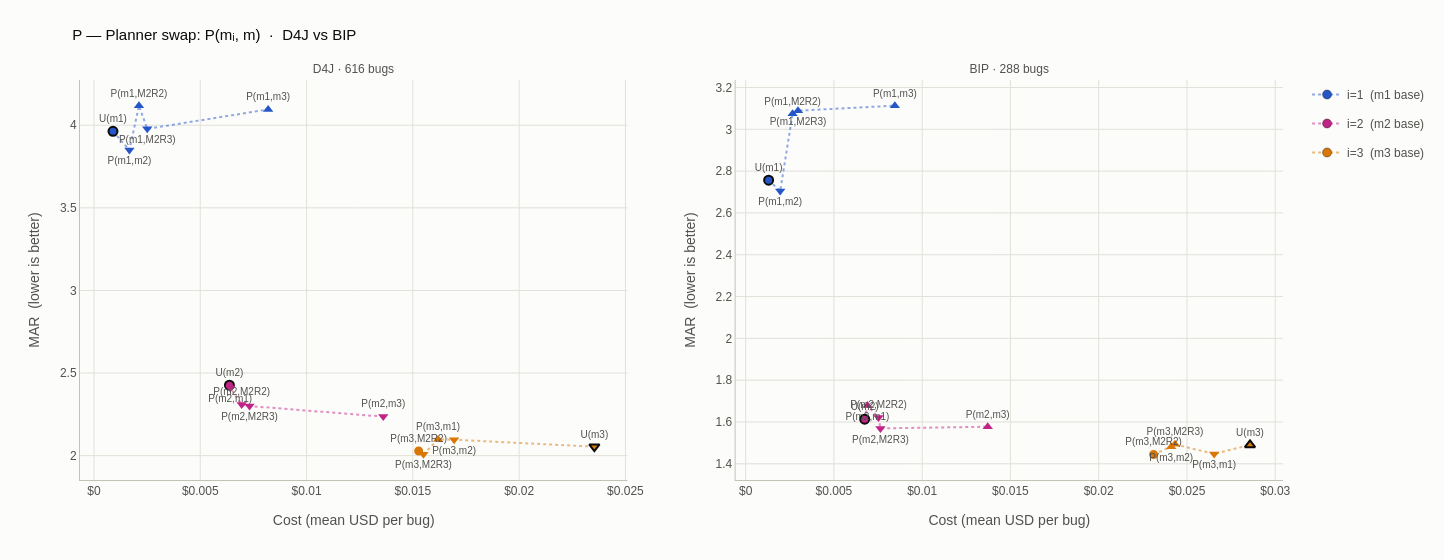

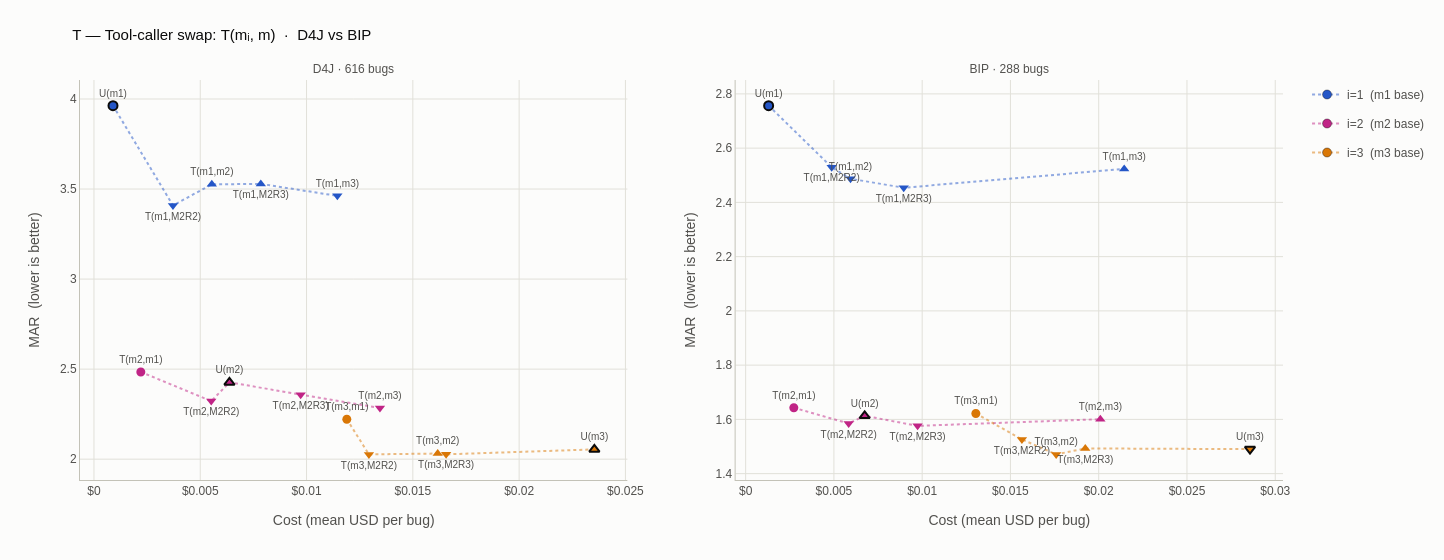

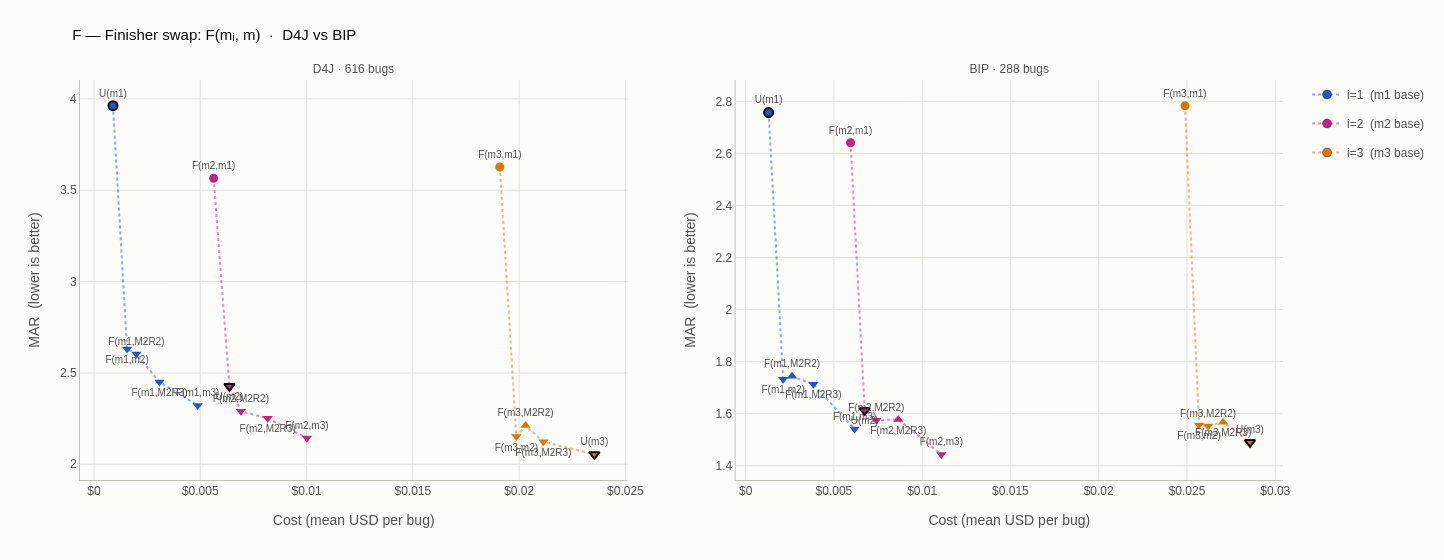

In [13]:
for fig in side_by_side_per_phase():
    save_fig(fig).show()

### Defects4J (D4J)

Per-phase plots for D4J alone, then the per-instance MAR table and its $(X, i)$ aggregate. `U-Min` is the headroom of the best swap below the uniform anchor, `Max-Min` the dynamic range of the swap — both are functions of $(X, i)$, so they repeat across the 5 swap rows of a group in the per-instance table.

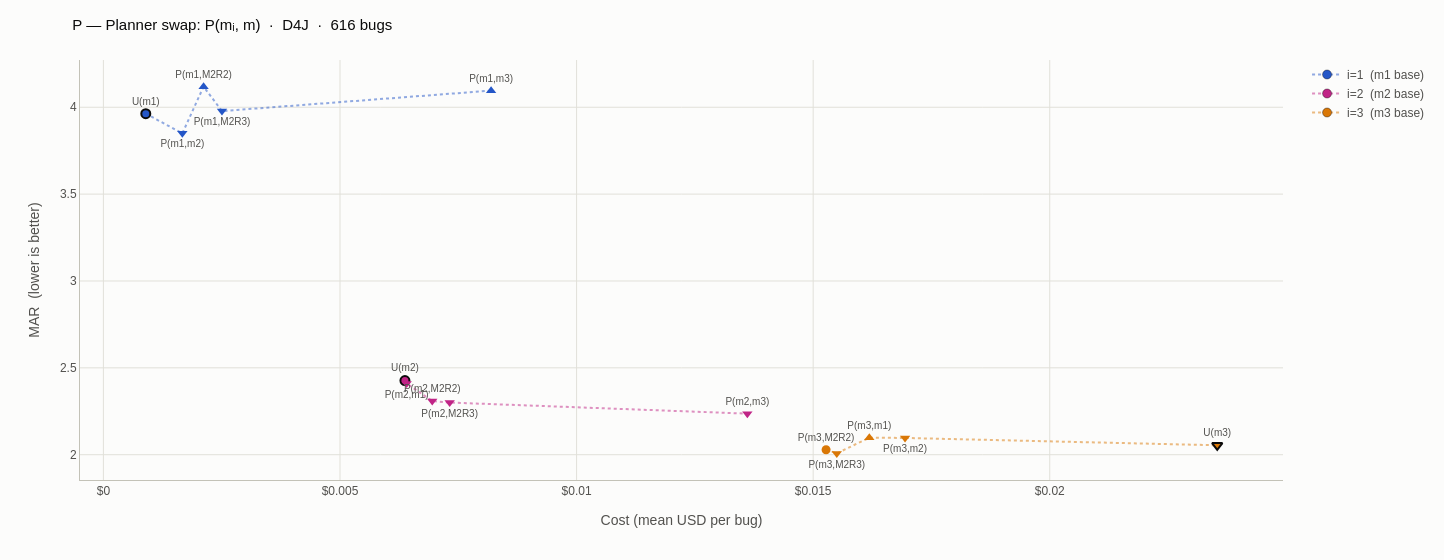

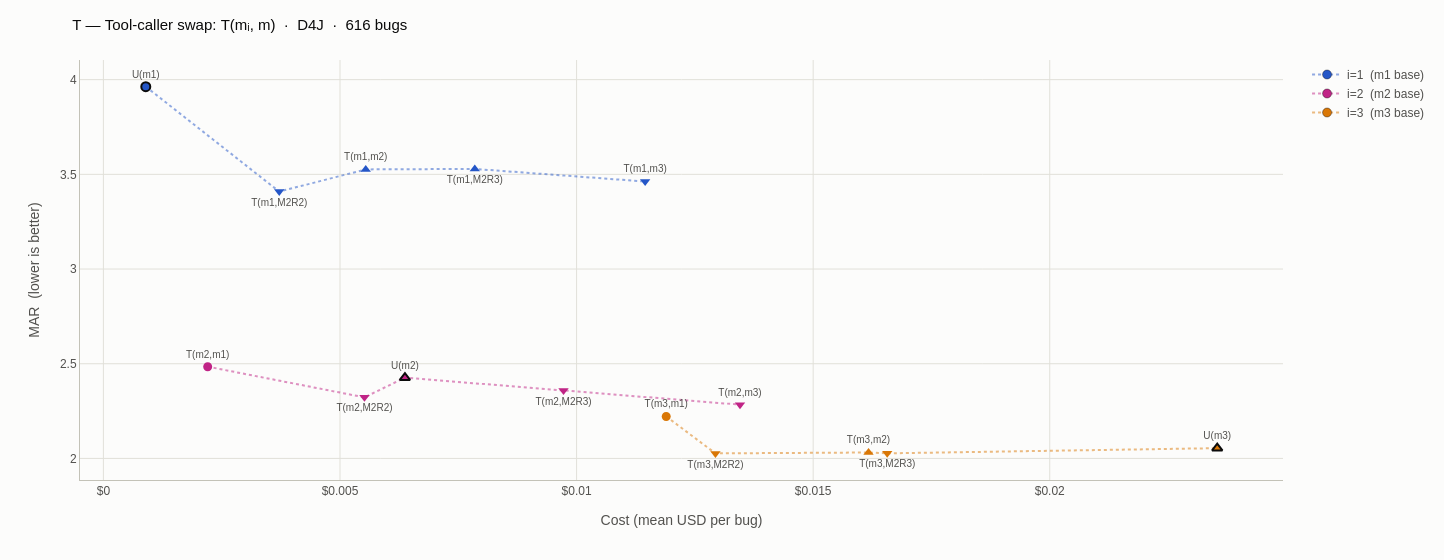

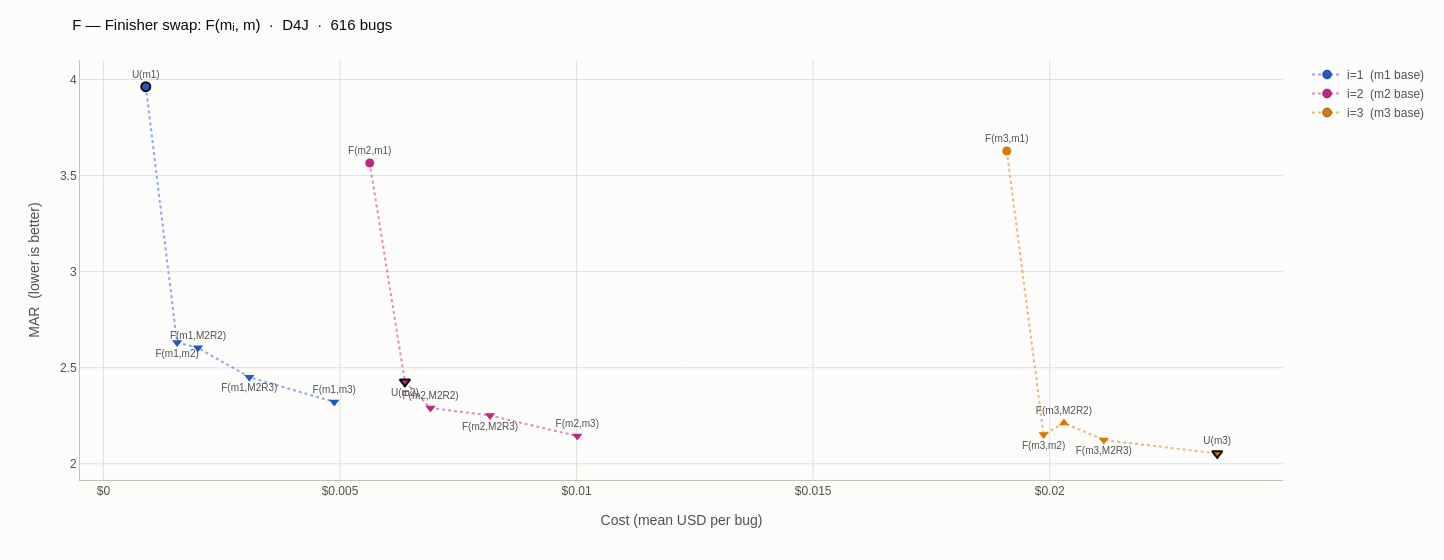

In [14]:
for fig in per_phase_figures("D4J"):
    save_fig(fig).show()

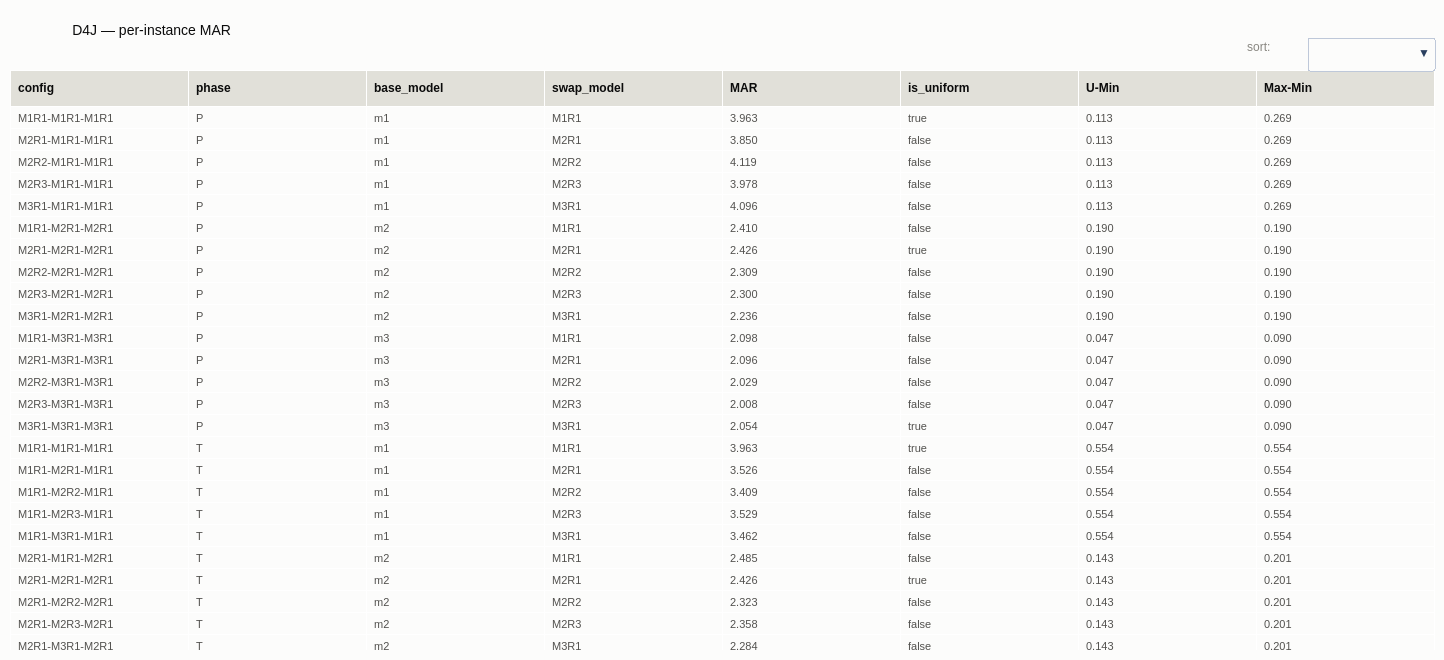

In [15]:
sortable_table(
    save_table(instance_table("D4J", "MAR"), "q1_mar_d4j_instances"),
    title="D4J — per-instance MAR",
)

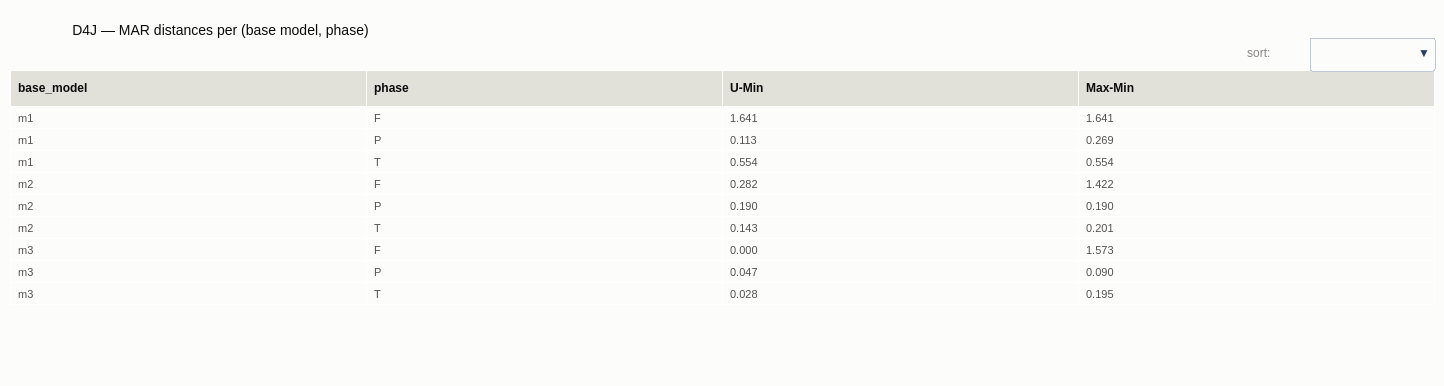

In [16]:
sortable_table(
    save_table(group_table("D4J", "MAR"), "q1_mar_d4j_groups"),
    title="D4J — MAR distances per (base model, phase)",
)

### BugsInPy (BIP)

The same three views on BIP.

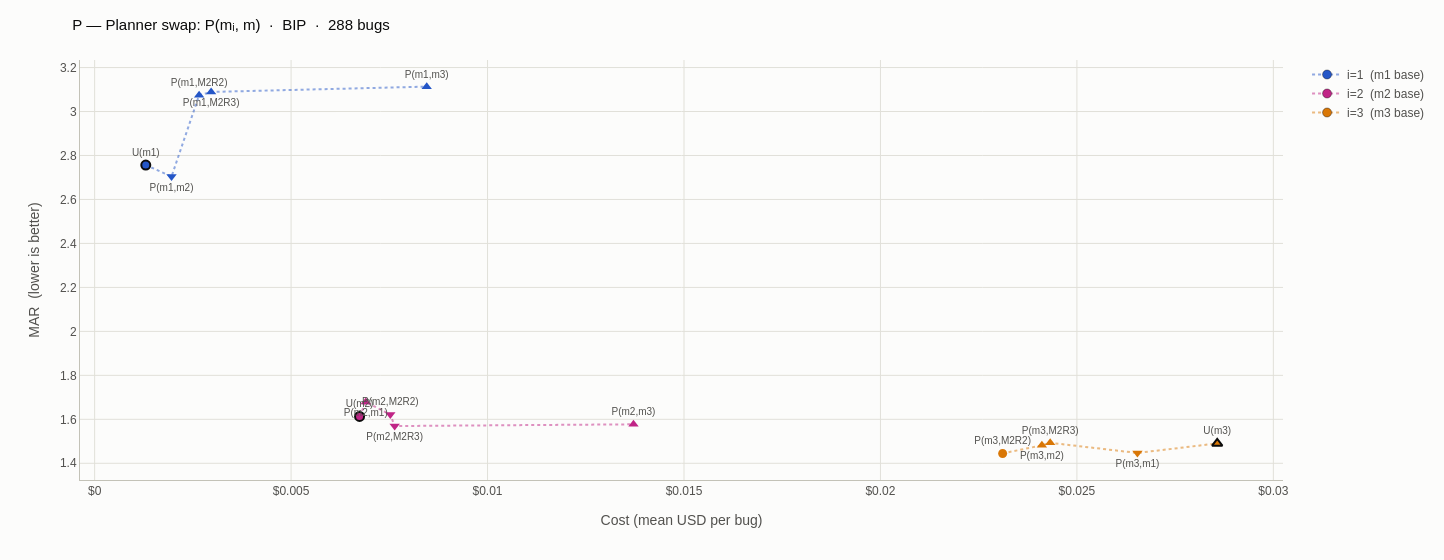

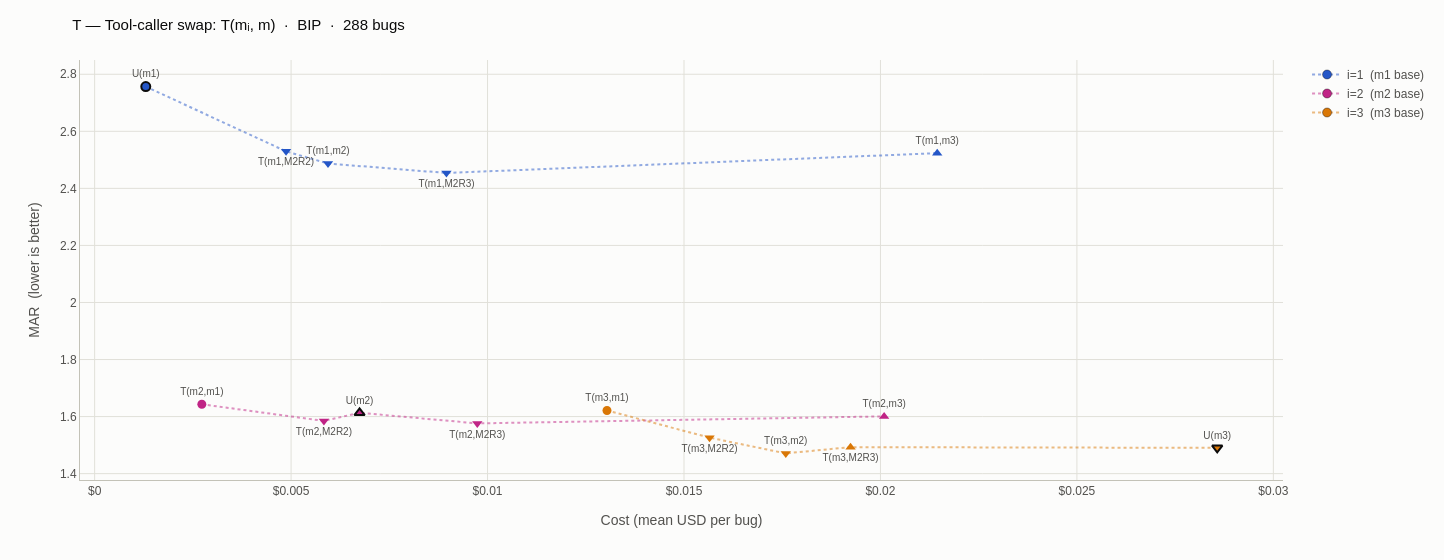

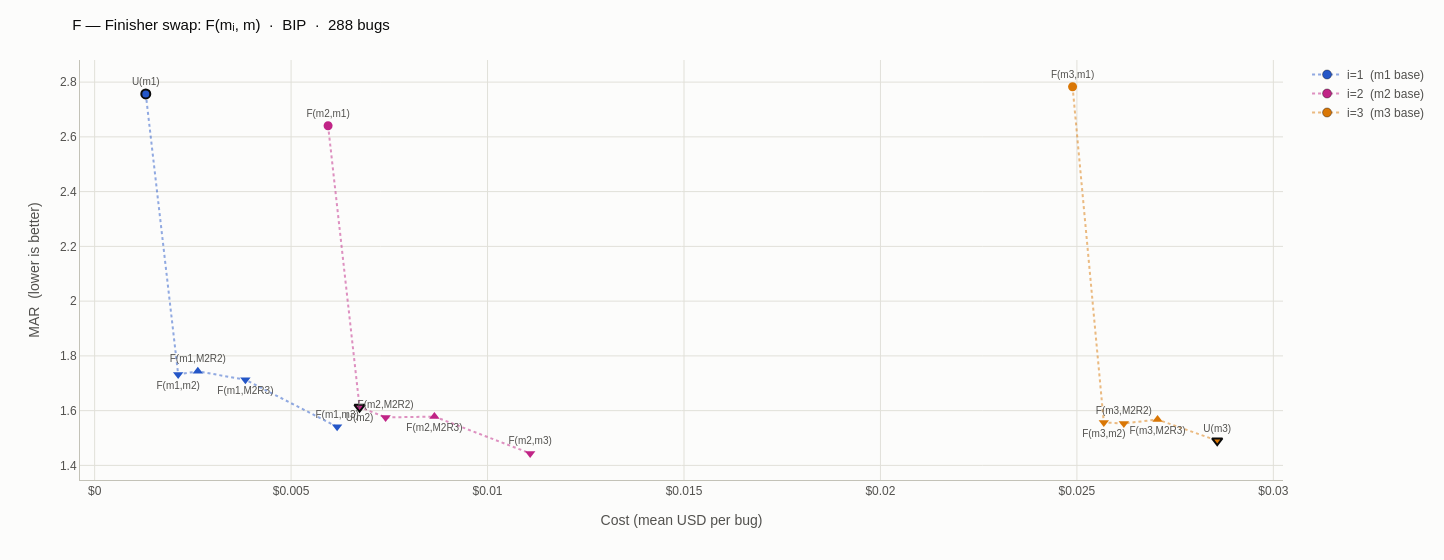

In [17]:
for fig in per_phase_figures("BIP"):
    save_fig(fig).show()

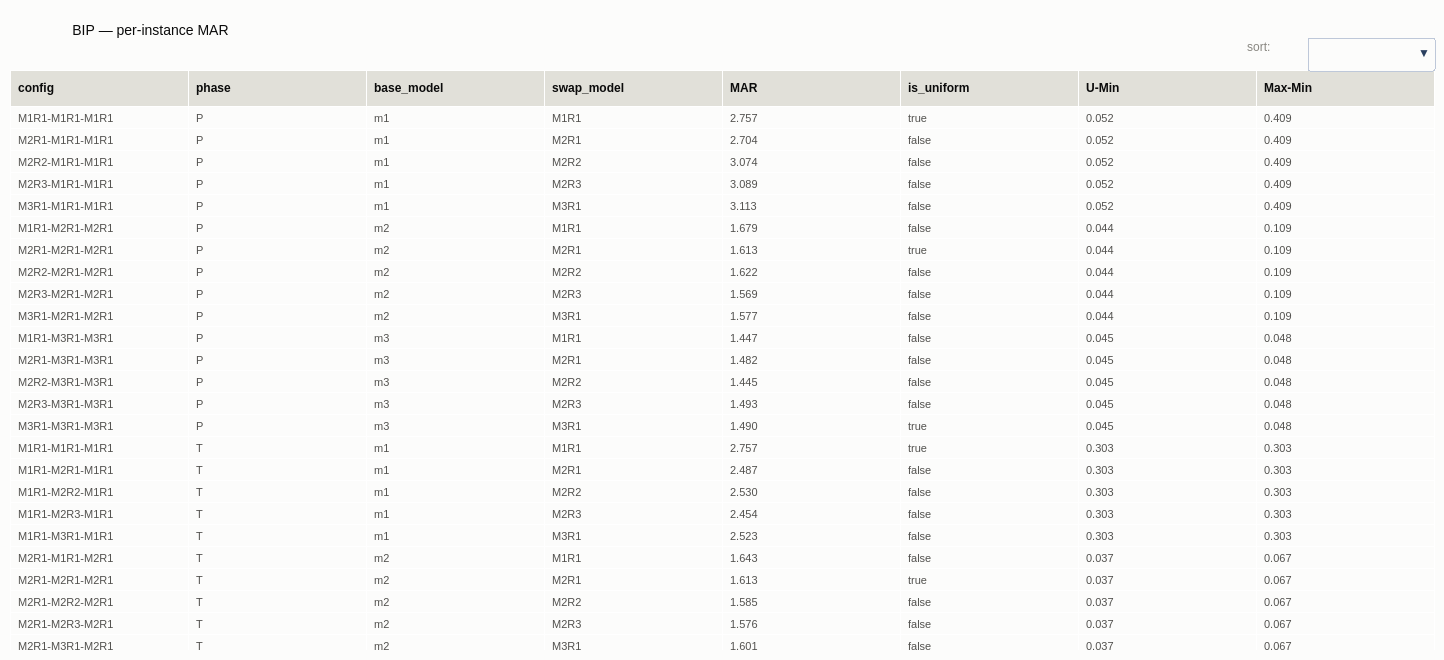

In [18]:
sortable_table(
    save_table(instance_table("BIP", "MAR"), "q1_mar_bip_instances"),
    title="BIP — per-instance MAR",
)

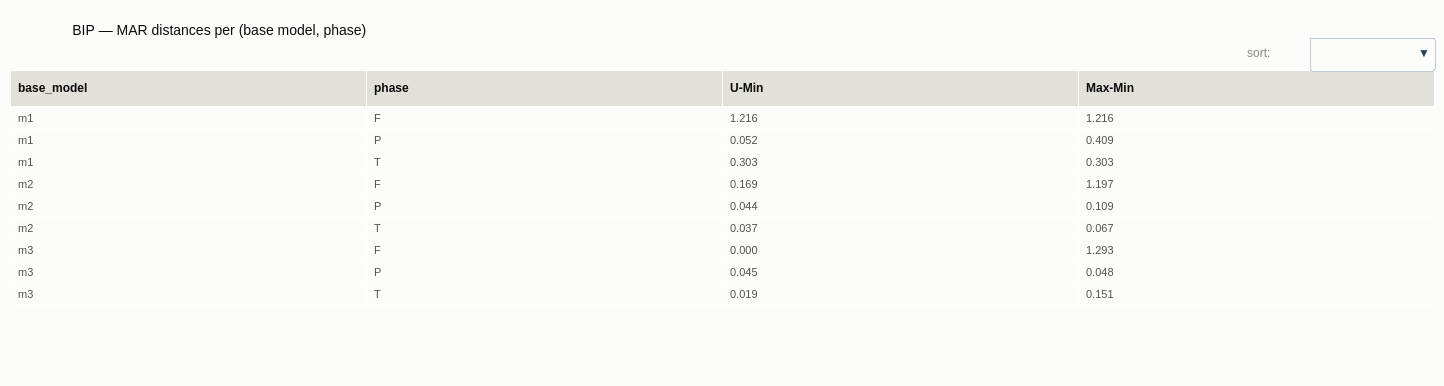

In [19]:
sortable_table(
    save_table(group_table("BIP", "MAR"), "q1_mar_bip_groups"),
    title="BIP — MAR distances per (base model, phase)",
)

### Per-project

Are the aggregate patterns above bug-agnostic, or driven by a few bug-heavy projects? The same three per-phase pareto plots, restyled: **solid** full-opacity lines are the benchmark-level series $X(m_i, m)$ (one per background tier, colored by tier as before); **dashed** 30%-opacity lines recompute the same series within each project (a point is the mean over that project's bugs only). Symbols encode the swept agent $m$; uniform anchors keep the ring outline. Points carry no labels — hover a faint point for its project, config, and bug count. Projects with fewer than `MIN_PROJECT_BUGS` (§0, currently 15) valid bug results are omitted — their means are too noisy to read as a trend. That keeps 13/17 D4J projects but only 5/17 BIP projects (keras, luigi, pandas, scrapy, youtube-dl), which together still cover ~72% of BIP's bugs.

#### Defects4J (D4J)

In [20]:
for fig in per_project_figures("D4J"):
    save_fig(fig).show()

#### BugsInPy (BIP)

In [21]:
for fig in per_project_figures("BIP"):
    save_fig(fig).show()

### Verdict (draft, from meeting notes)

**The Finisher affects FL accuracy the most, consistently across projects.** Max–Min(MAR) for $X=F$ dominates every other phase on both benchmarks (D4J: 1.42–1.64 vs ≤0.56 for P/T; BIP: 1.20–1.29 vs ≤0.41) — swapping the finisher can move MAR by more than a full rank, an order of magnitude beyond planner swaps. The per-project overlays repeat the pattern: the F-swap "vertical drop" from an $m_1$ finisher to anything larger appears within nearly every ≥15-bug project.

## 2. Which FlexFL role affects monetary/computational cost the most?

> *Alternate phrasing:* Which FlexFL role dominates the monetary/token cost of a run?

### Both benchmarks — per-phase view, side by side

The same per-phase pairs as in Q1 — the plots carry both axes, so nothing changes here; what changes below is which axis the tables read.

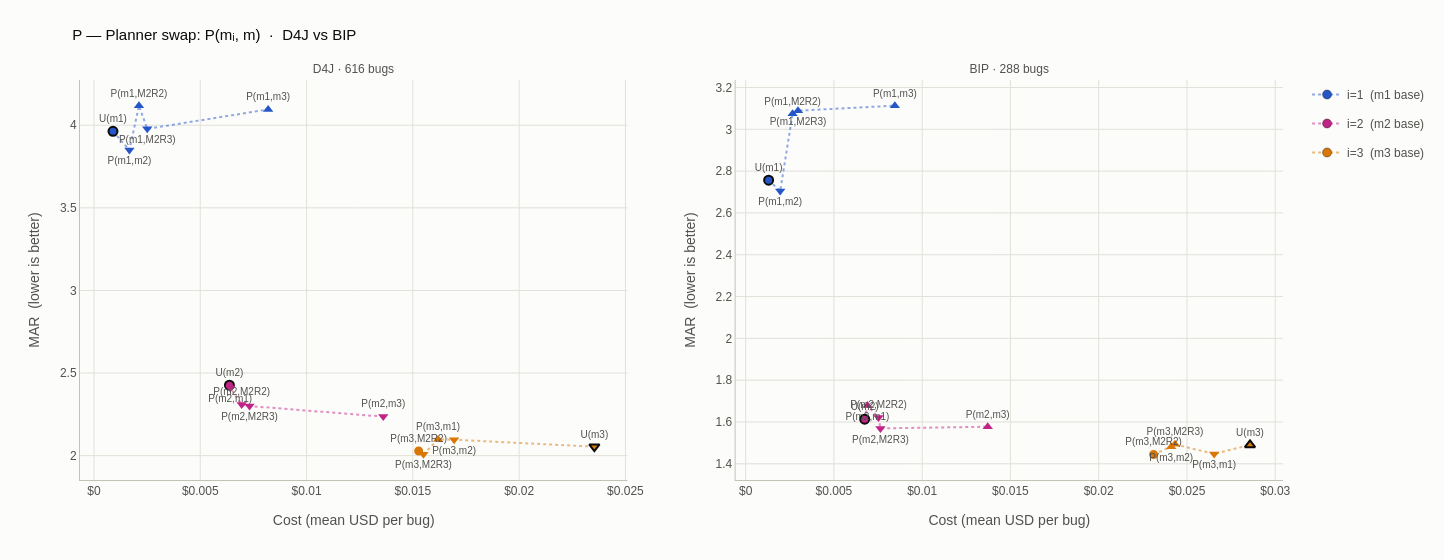

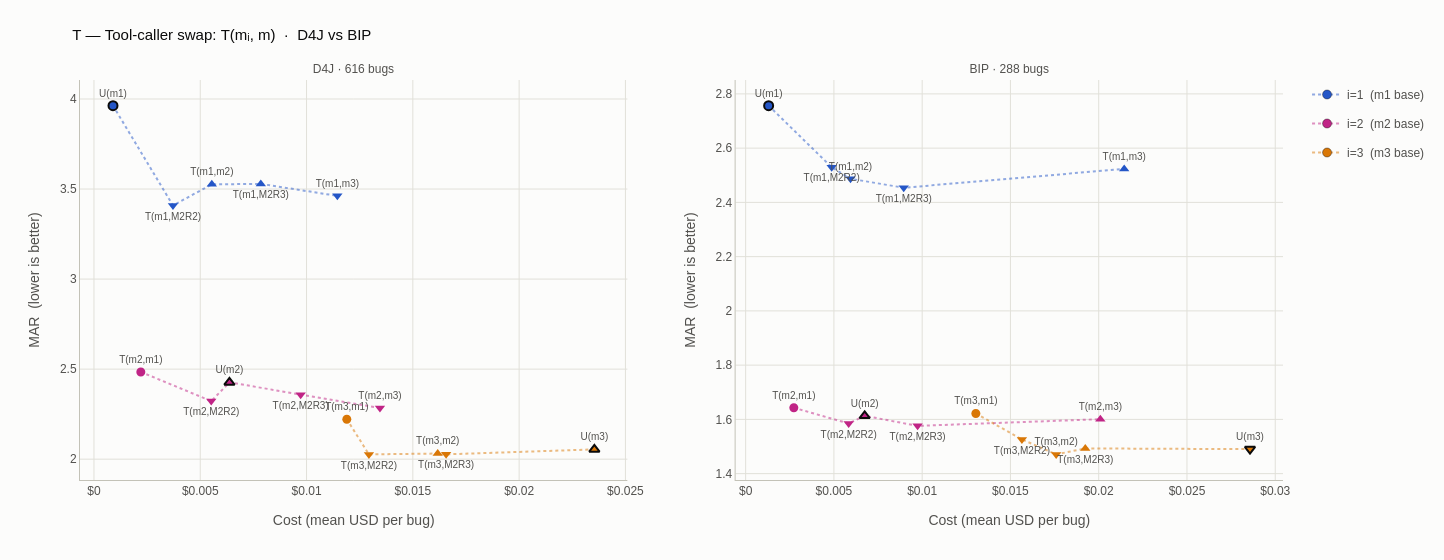

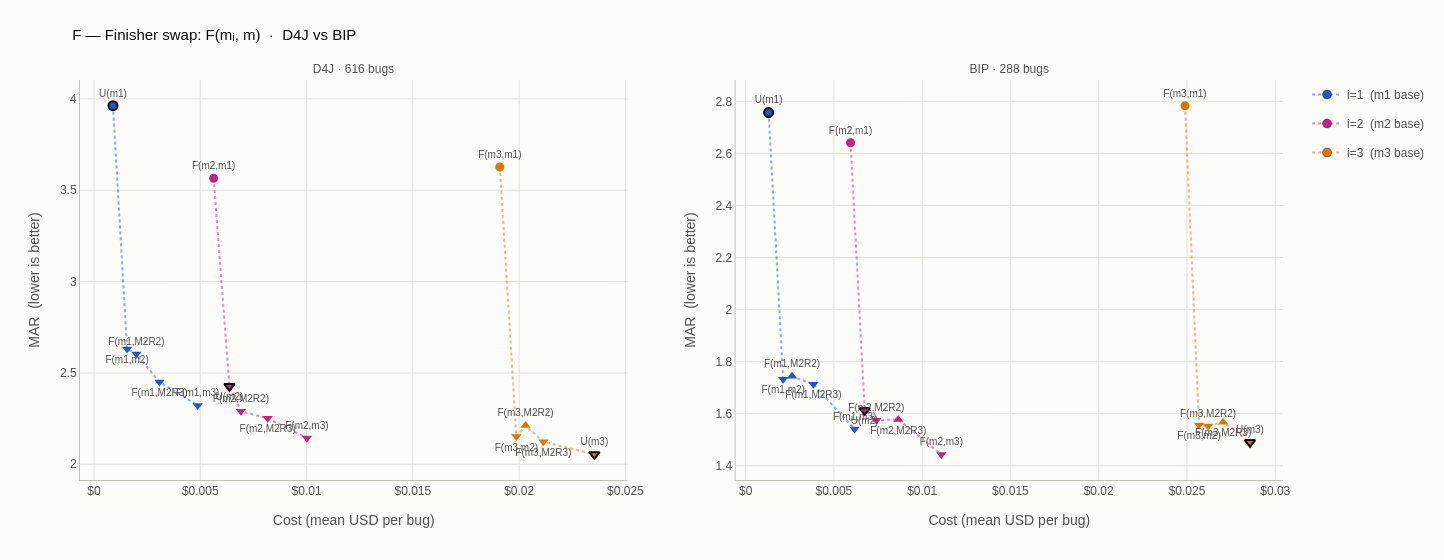

In [22]:
for fig in side_by_side_per_phase():
    save_fig(fig).show()

### Defects4J (D4J)

Per-phase plots for D4J alone, then the per-instance cost table and its $(X, i)$ aggregate. Cost appears on both scales: raw mean USD per bug, and min–max normalized to 0~1 over this benchmark's own 39-config cost range (each benchmark normalized over its own range). The normalized columns are the ones to compare against BIP; the dollar columns are the ones to budget with.

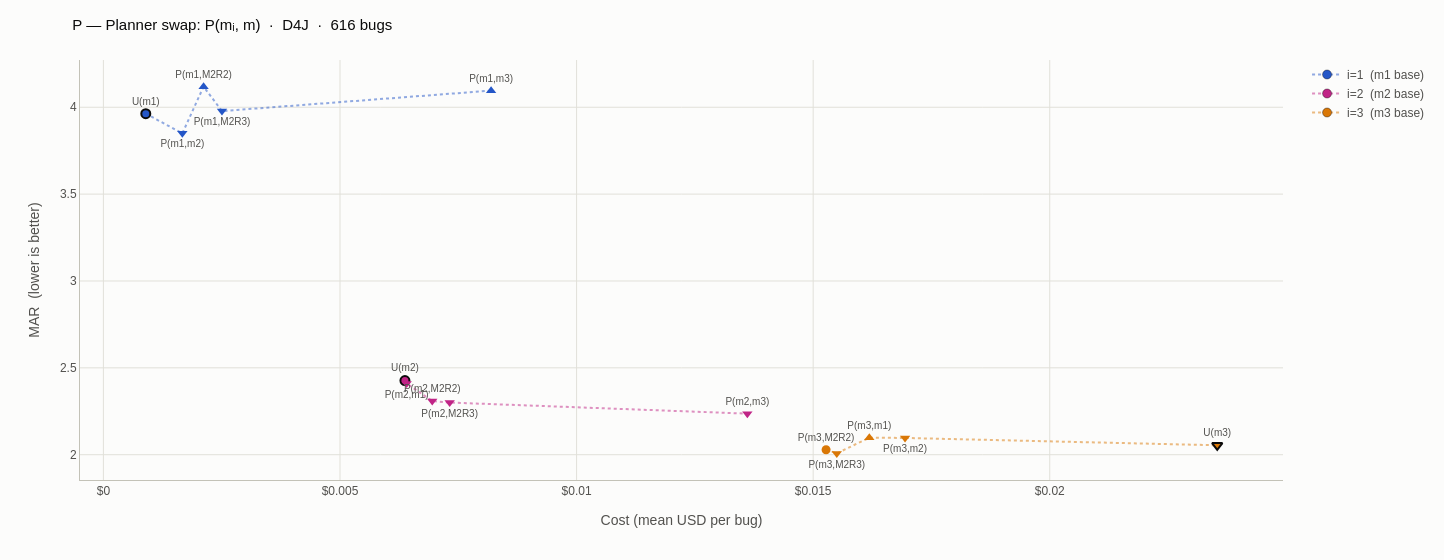

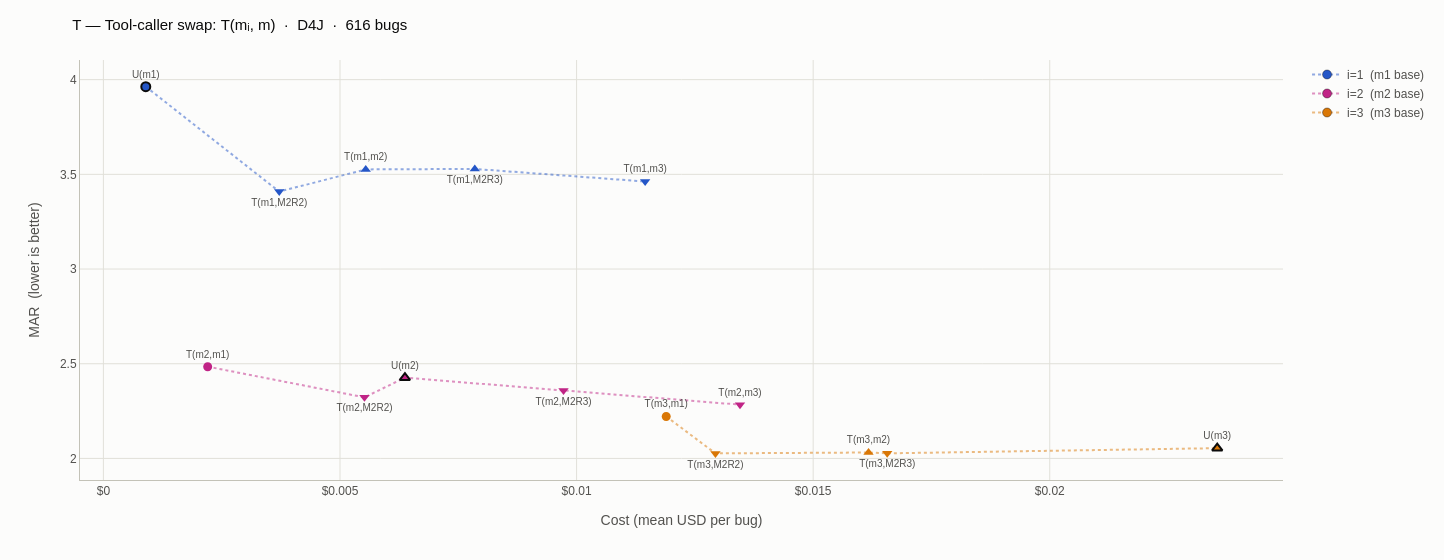

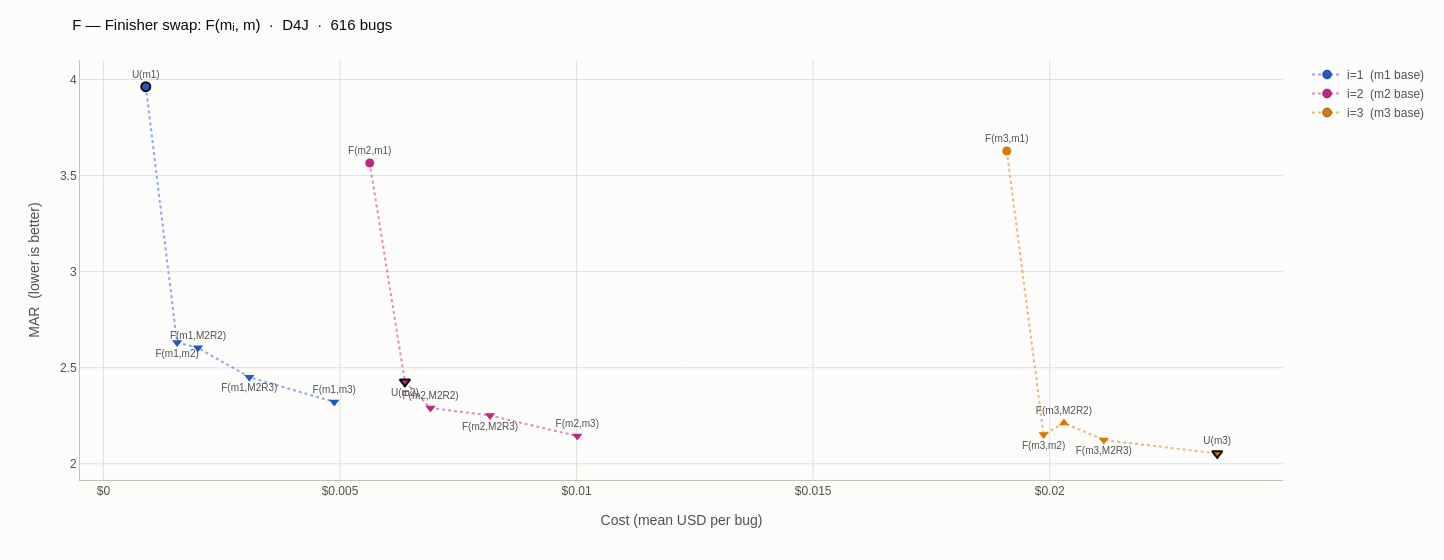

In [23]:
for fig in per_phase_figures("D4J"):
    save_fig(fig).show()

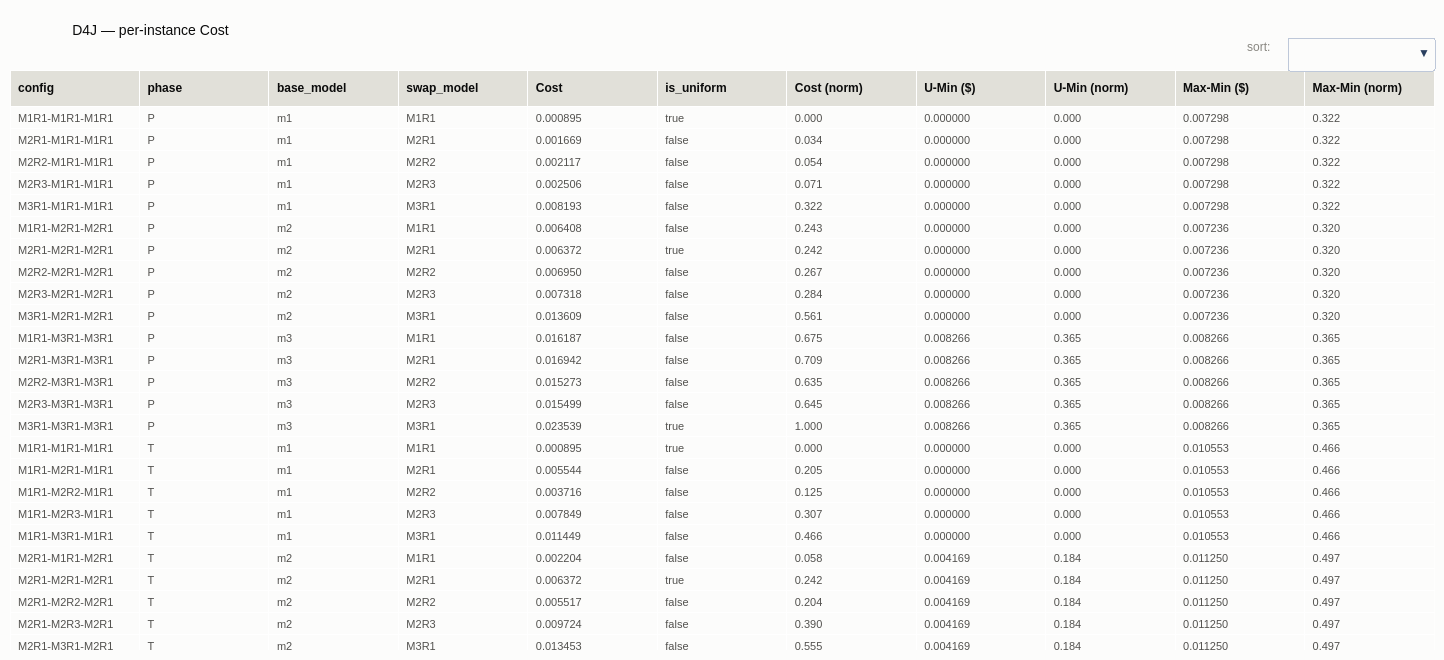

In [24]:
sortable_table(
    save_table(instance_table("D4J", "Cost"), "q2_cost_d4j_instances"),
    title="D4J — per-instance Cost",
)

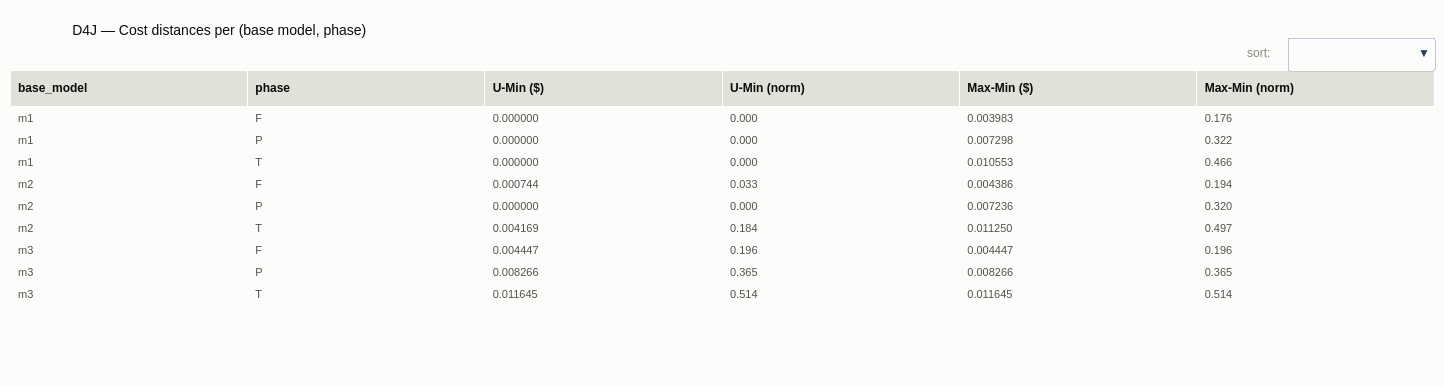

In [25]:
sortable_table(
    save_table(group_table("D4J", "Cost"), "q2_cost_d4j_groups"),
    title="D4J — Cost distances per (base model, phase)",
)

### BugsInPy (BIP)

The same three views on BIP. Note the normalization range is BIP's own ($0.0013–$0.0286 per bug), not D4J's.

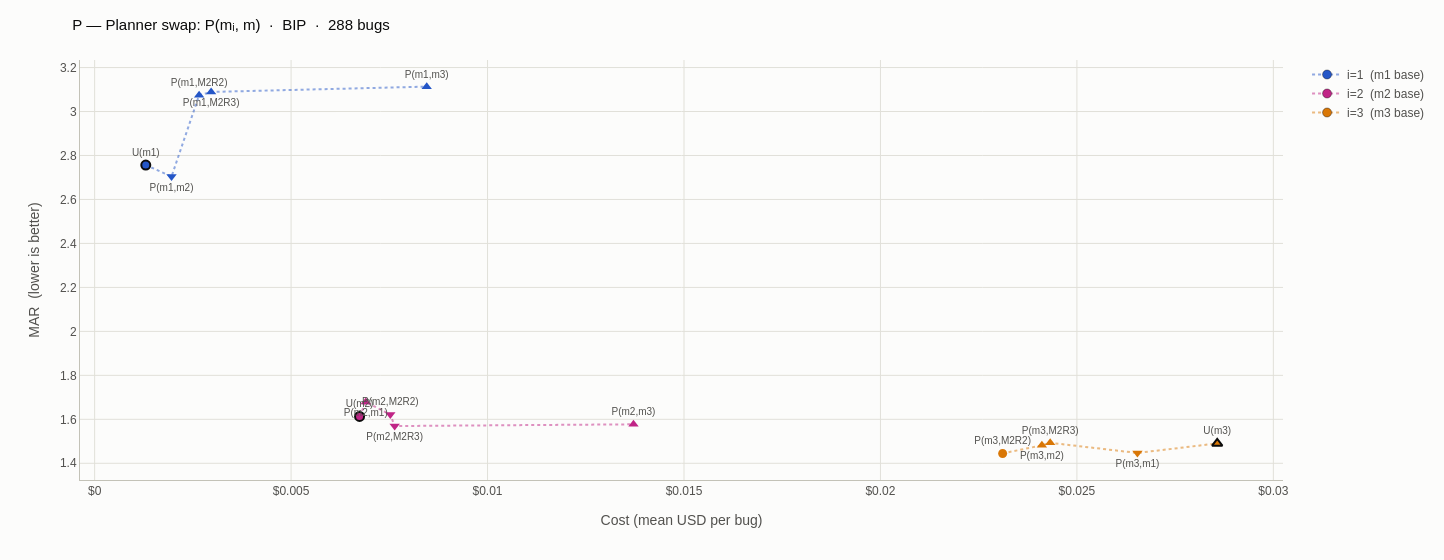

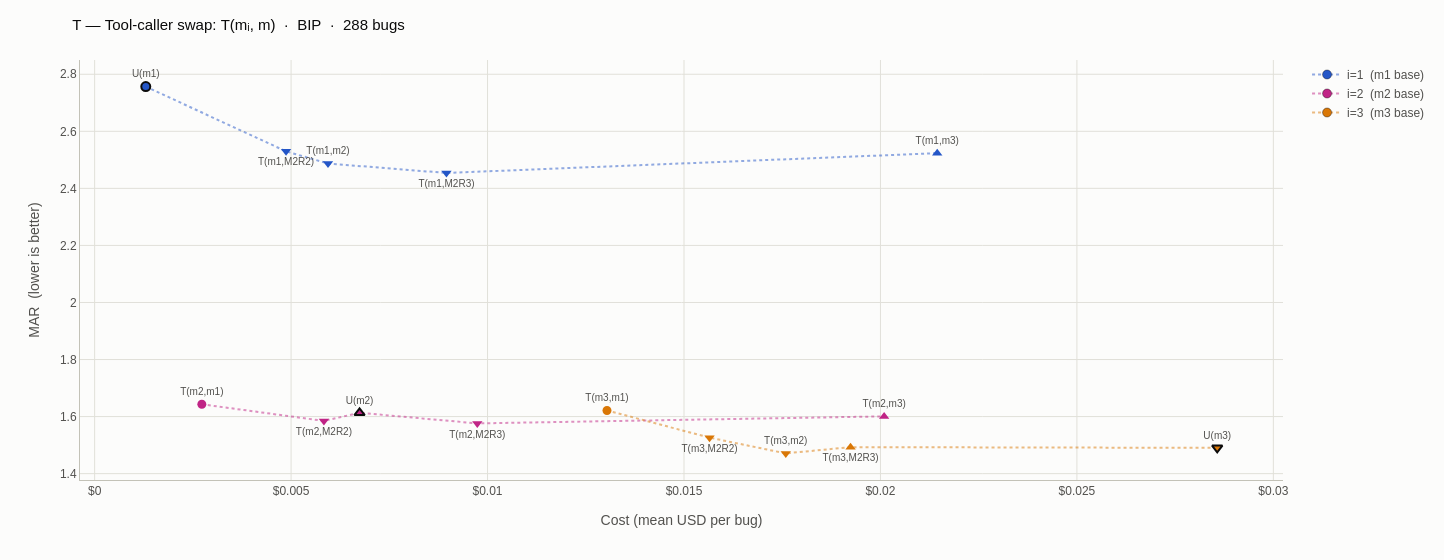

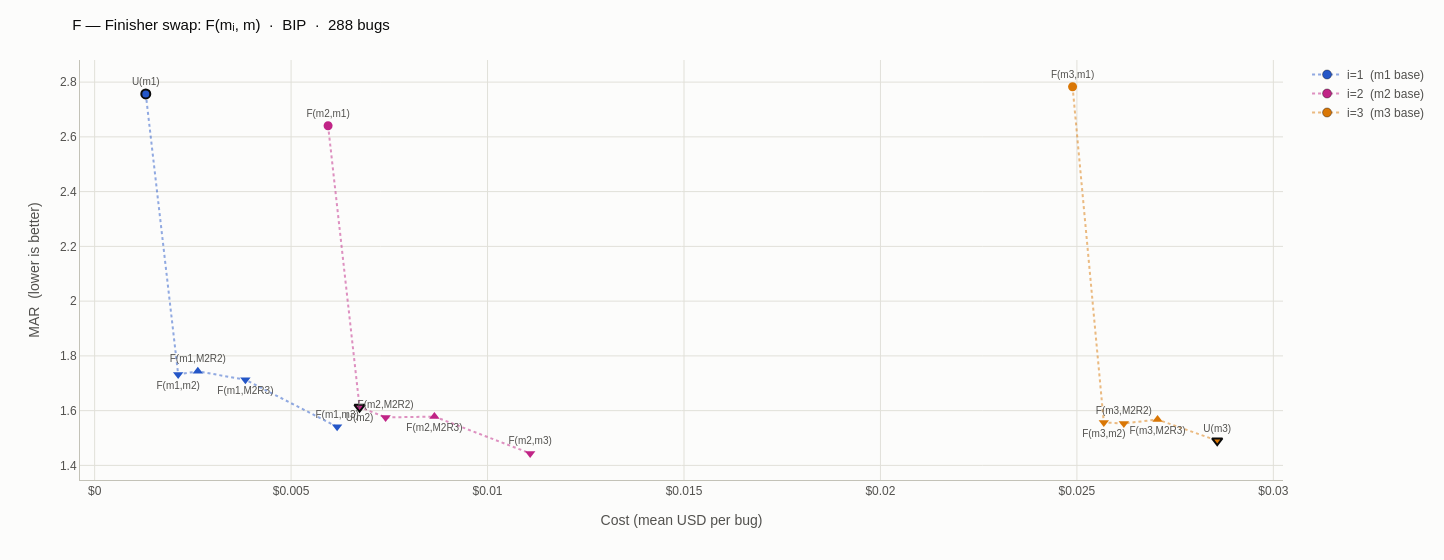

In [26]:
for fig in per_phase_figures("BIP"):
    save_fig(fig).show()

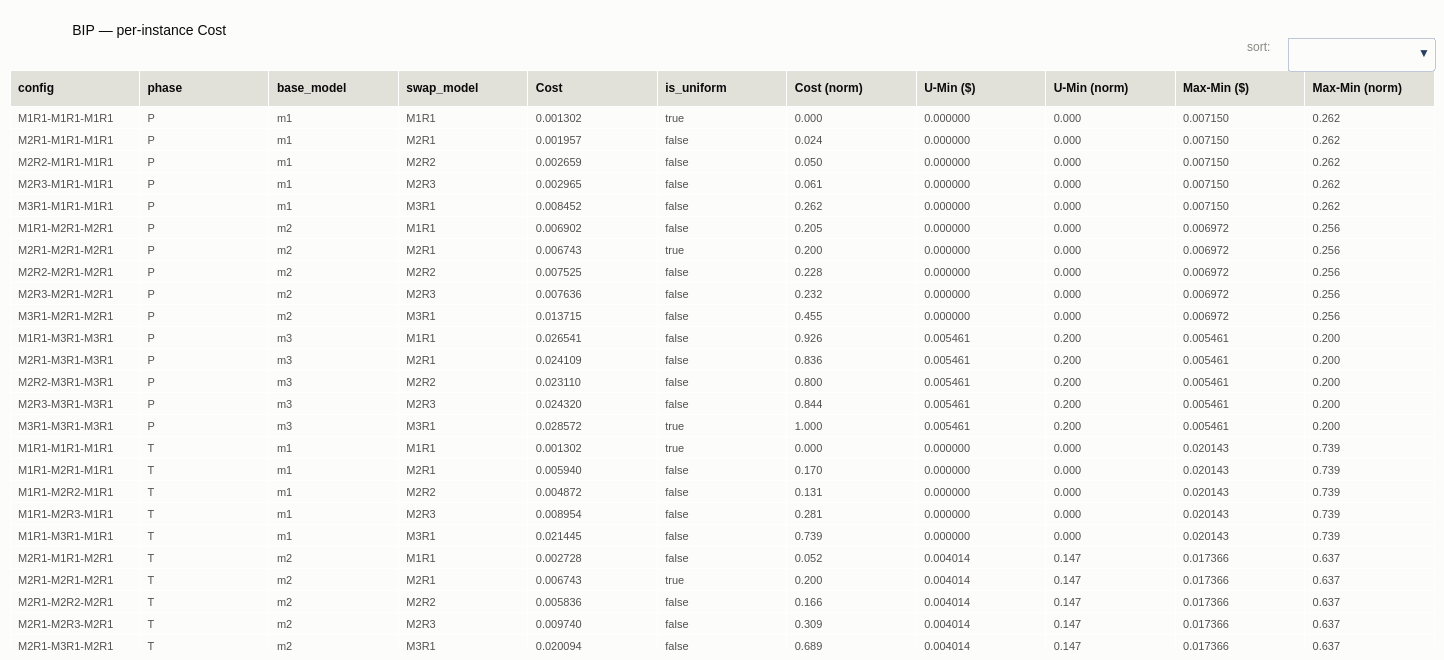

In [27]:
sortable_table(
    save_table(instance_table("BIP", "Cost"), "q2_cost_bip_instances"),
    title="BIP — per-instance Cost",
)

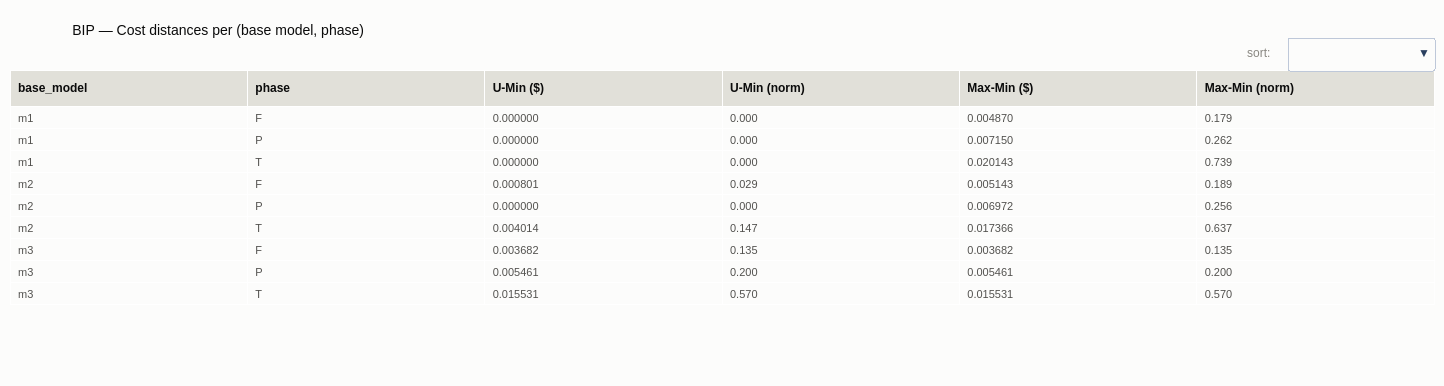

In [28]:
sortable_table(
    save_table(group_table("BIP", "Cost"), "q2_cost_bip_groups"),
    title="BIP — Cost distances per (base model, phase)",
)

### Per-project

The same per-project view as in Q1 — the pareto carries both targets, so here the reading is horizontal (cost spread) rather than vertical: are per-project cost orderings as stable as the aggregate ones?

#### Defects4J (D4J)

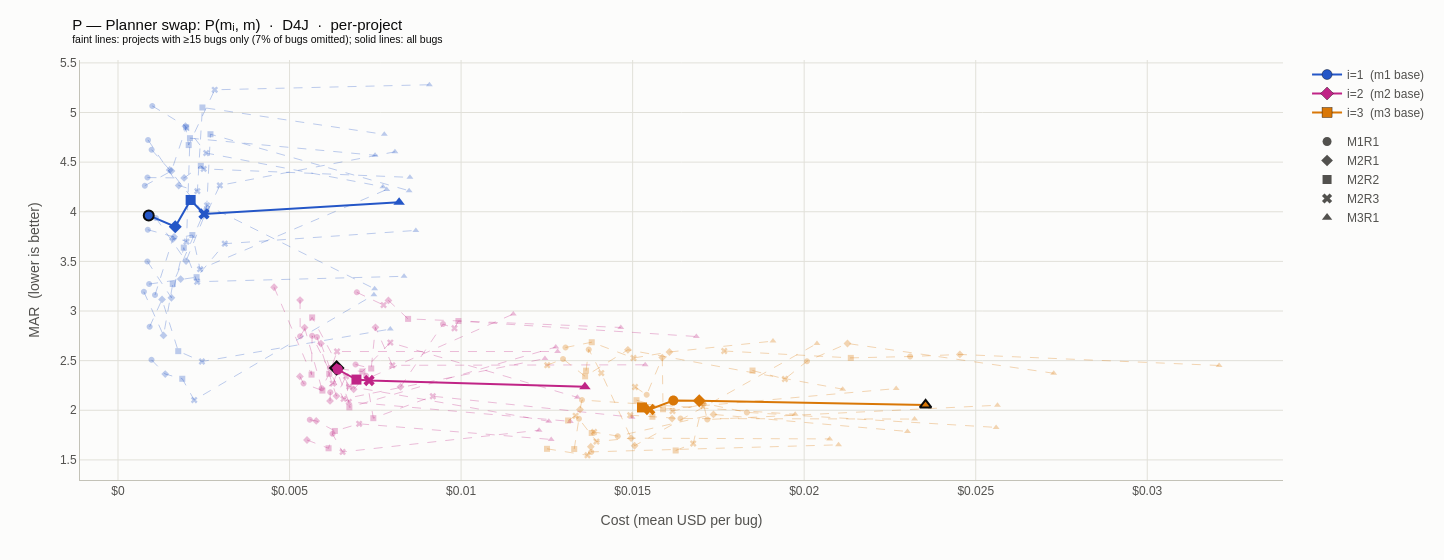

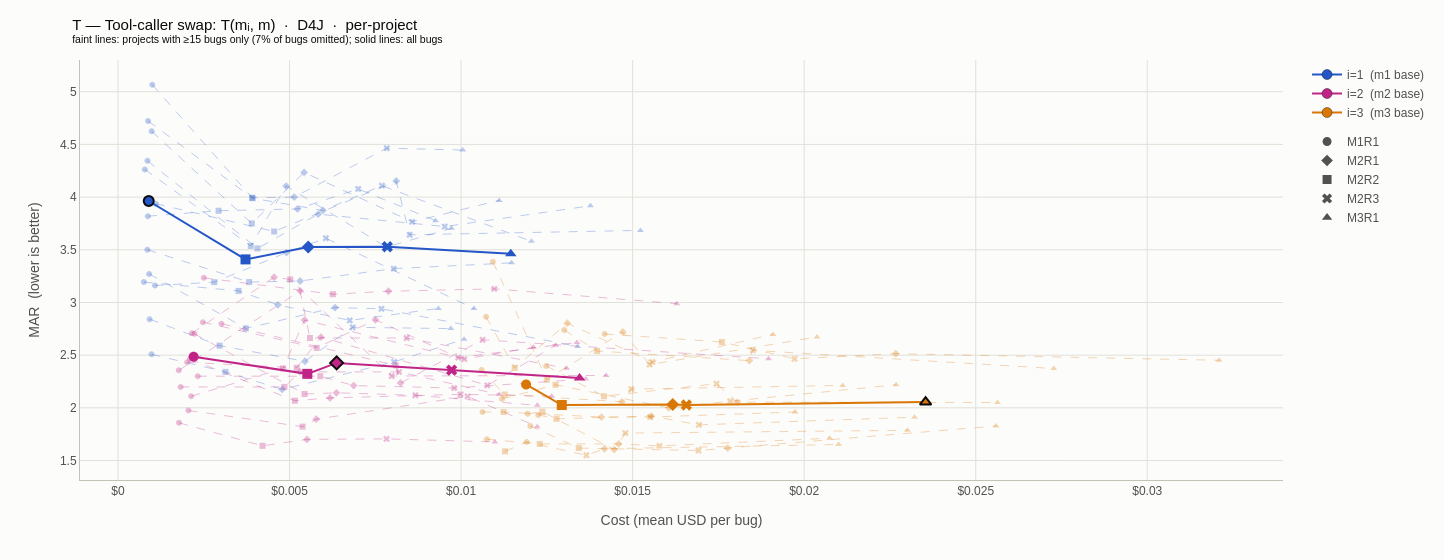

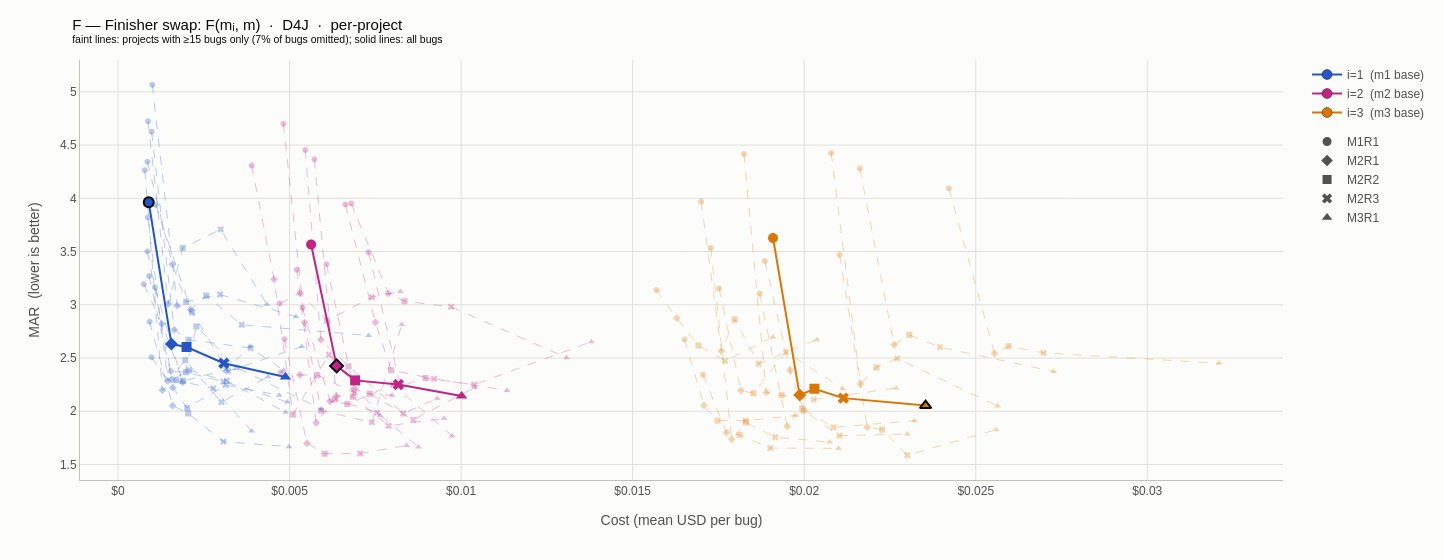

In [29]:
for fig in per_project_figures("D4J"):
    save_fig(fig).show()

#### BugsInPy (BIP)

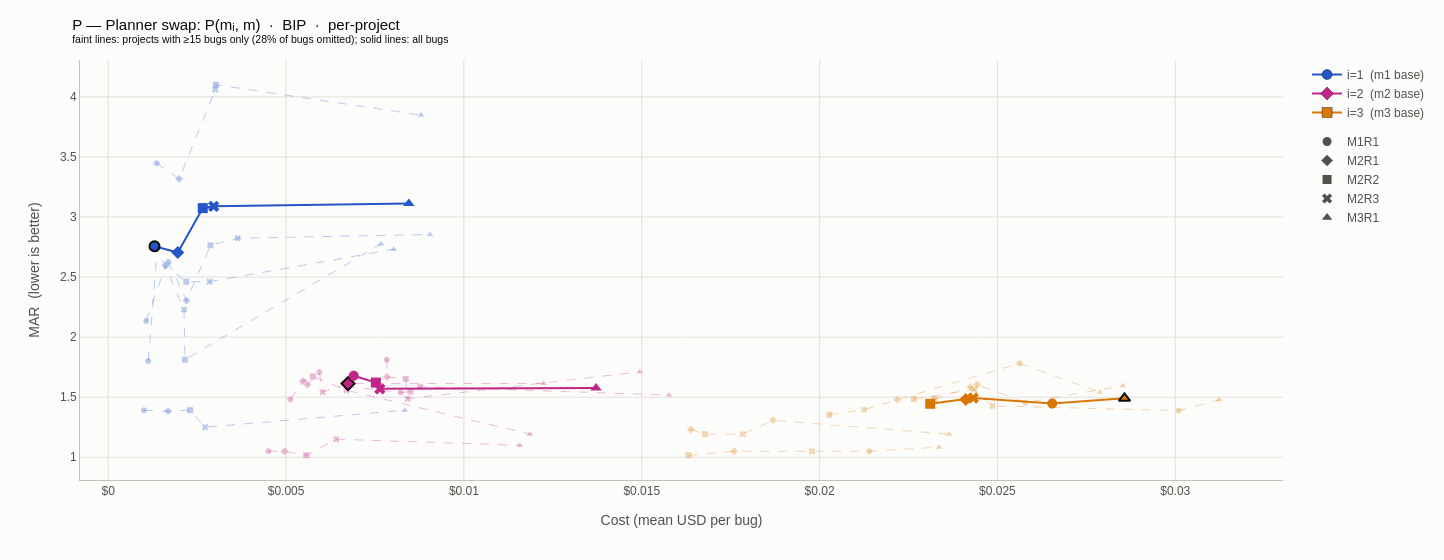

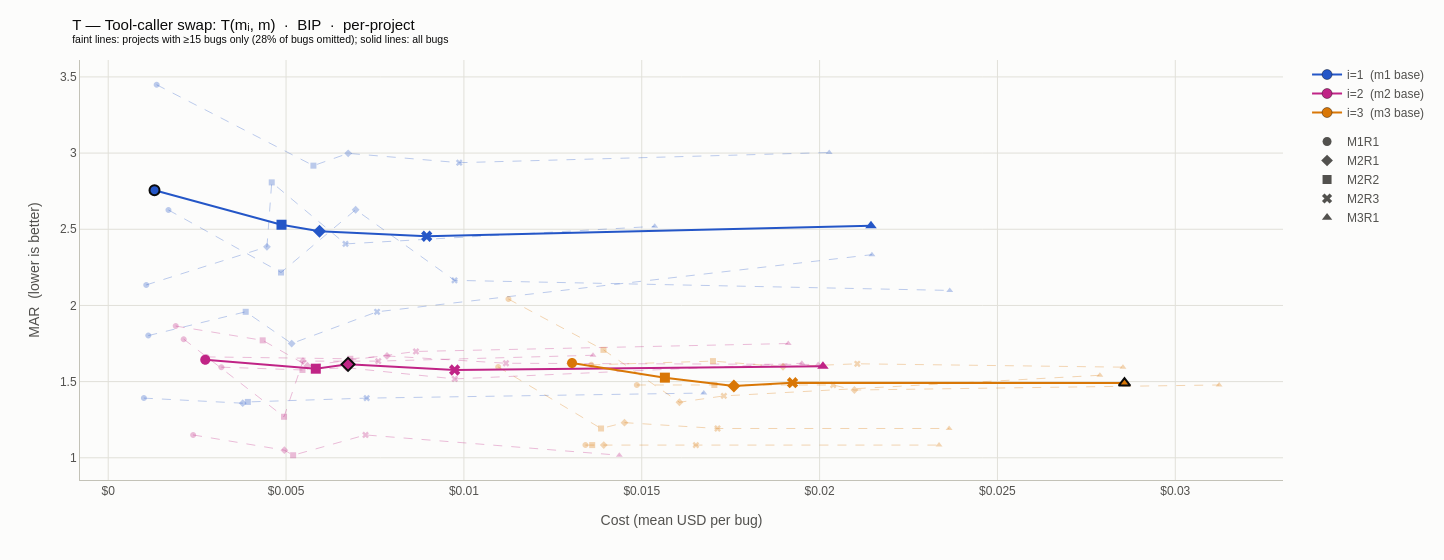

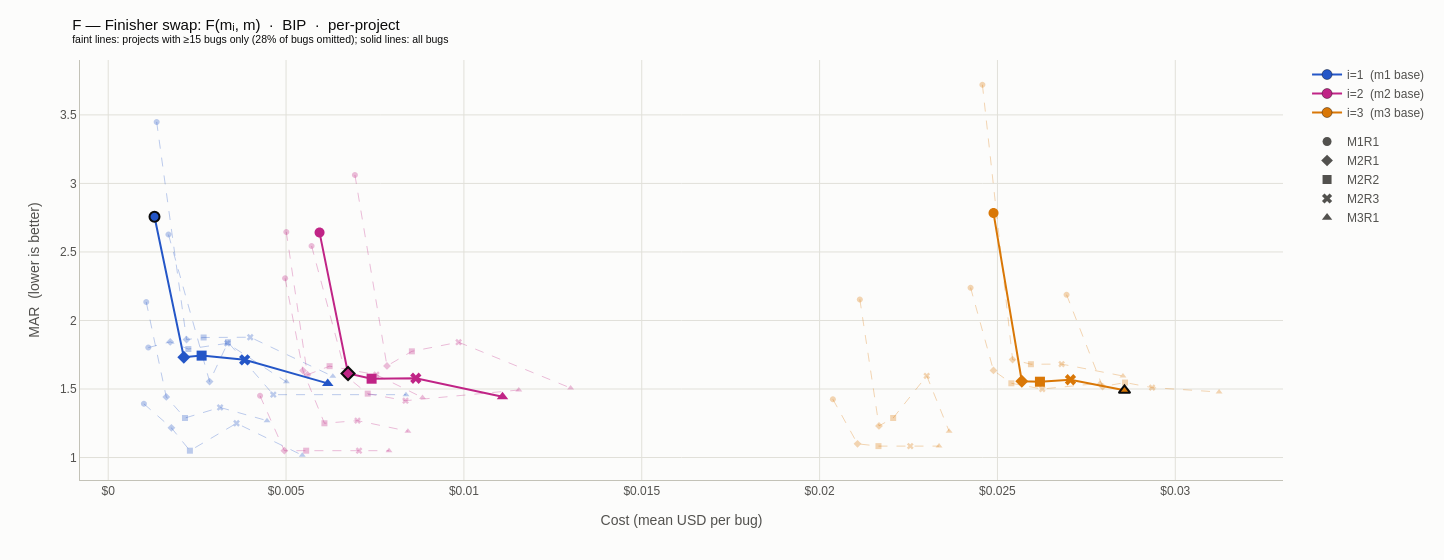

In [30]:
for fig in per_project_figures("BIP"):
    save_fig(fig).show()

### Verdict (draft, from meeting notes)

**The Tool-caller affects cost the most, consistently across projects.** Max–Min(Cost, norm) is highest for $X=T$ in every base tier on both benchmarks (D4J: 0.47–0.51 vs ≤0.37 for P and ≤0.20 for F; BIP: 0.57–0.74 vs ≤0.26 and ≤0.19) — expected, as the tool-calling phase runs the most iterations and carries the bulk of the tokens, so its price multiplies through. The per-project overlays show the same horizontal (cost) spread ordering within projects.

## 3. Does a higher reasoning effort for FlexFL yield better FL accuracy?

> *Alternate phrasing:* Does raising a role's reasoning effort improve FlexFL's FL accuracy?

**Draft interpretation of the notes — updated with the off-grid uniform runs.** The notes' check — $MAR(U(m_x, R_i))$ vs $MAR(U(m_x, R_{i+1}))$ — is now directly computable on the tier-2 model: $U(M2R2)$ and $U(M2R3)$ exist on **both** benchmarks (D4J from the original sweep, BIP from the 2026-08-24 batch), read from each benchmark's `evaluation/<BM>/flexfl.csv` on its own full-sweep panel via the §0 helpers. The **uniform reading** is therefore the primary answer: does raising the reasoning effort of *every* role at once improve accuracy? "Higher effort → better accuracy" predicts MAR falling along $U(M2R1) \rightarrow U(M2R2) \rightarrow U(M2R3)$. The **per-role** sweeps below it (a single role swept R1→R2→R3 of the tier-2 model on each base $m_i$) remain the finer-grained secondary reading; the $i=2$ series starts at its uniform anchor $U(m_2)$ (ring-marked).

**Columns of the sweep tables below** (9 rows = 3 phases × 3 base tiers). MAR is the mean average rank of the fault — **lower is better**, so an improvement is a *negative* delta.

- `phase` — the single role whose model is swapped: `P` Planner, `T` Tool-caller, `F` Finisher.
- `base_model` — the tier $m_i$ every *other* role keeps.
- `MAR@R1` / `MAR@R2` / `MAR@R3` — MAR with the tier-2 model at that reasoning effort in the swapped role. The $i=2$ row starts at the uniform anchor $U(m_2)$ (ring-marked in the plot).
- `d(R2-R1)` / `d(R3-R2)` — change per reasoning step; negative = more reasoning helped.
- `monotone better` — `True` iff MAR falls strictly at both steps, i.e. the notes' inequality holds throughout for this (phase, base) group.

The printed line counts how many of the 9 groups improve at each step — the aggregate answer to the question.

### Uniform, both benchmarks

Paired per-bug bootstrap CIs (95%) on the mean AR delta of each step: negative = the step improves accuracy; an interval clear of 0 = significant at the panel size.

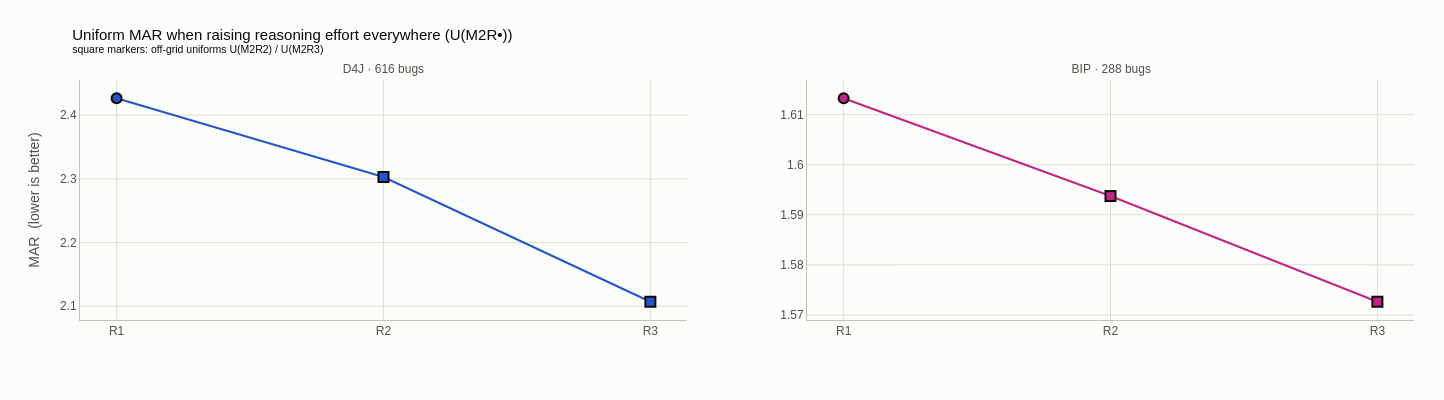

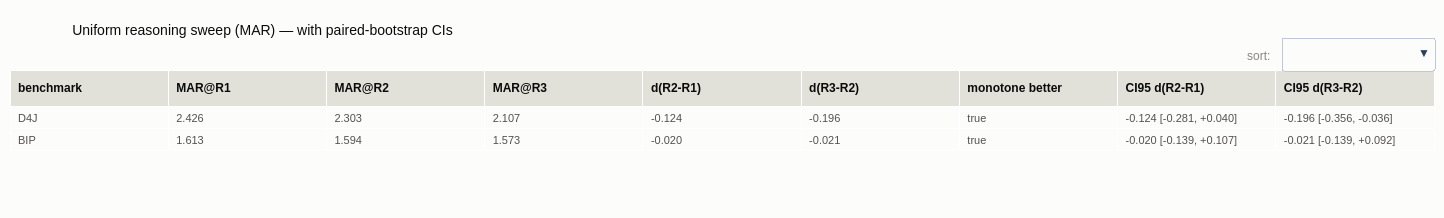

In [31]:
# Uniform reasoning sweep: MAR of raising the whole agent's effort one step
# at a time on the tier-2 model.
save_fig(
    uniform_axis_figure(
        R_FAMILY, FAMILY_TICKS["R"], "MAR",
        title="Uniform MAR when raising reasoning effort everywhere (U(M2R•))",
    ),
    "q3_uniform_reasoning_sweep_mar",
).show()
sortable_table(
    save_table(
        uniform_axis_table(R_FAMILY, FAMILY_TICKS["R"], "MAR", ci=True),
        "q3_uniform_reasoning_sweep_mar",
    ),
    title="Uniform reasoning sweep (MAR) — with paired-bootstrap CIs",
).show()

### Defects4J (D4J)

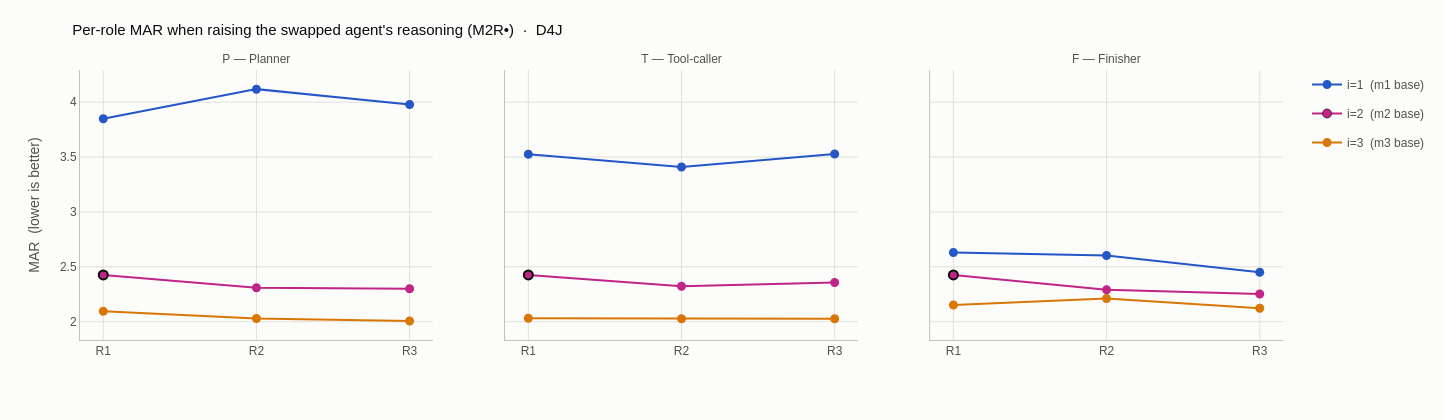

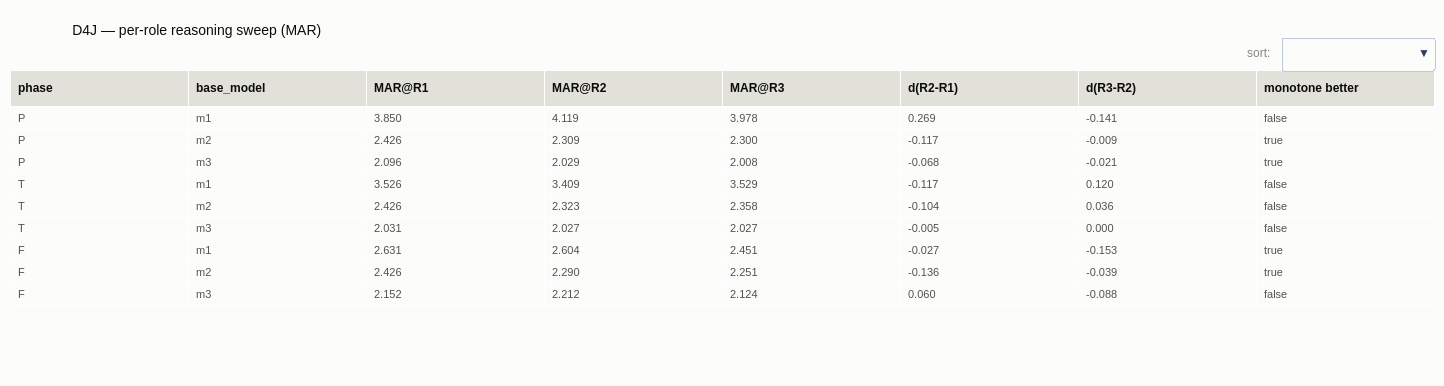

D4J: R2 beats R1 in 7/9 groups; R3 beats R2 in 6/9; R3 beats R1 in 7/9


In [32]:
save_fig(
    sweep_figure(
        "D4J", R_FAMILY, FAMILY_TICKS["R"], "MAR",
        title="Per-role MAR when raising the swapped agent's reasoning (M2R•)  ·  D4J",
    ),
    "q3_d4j_per_role_reasoning_sweep_mar",
).show()
sortable_table(
    save_table(
        sweep_table("D4J", R_FAMILY, FAMILY_TICKS["R"], "MAR"),
        "q3_d4j_per_role_reasoning_sweep_mar",
    ),
    title="D4J — per-role reasoning sweep (MAR)",
).show()
w = sweep_verdict("D4J", R_FAMILY, "MAR")
print(f"D4J: R2 beats R1 in {w[0]}/9 groups; R3 beats R2 in {w[1]}/9; R3 beats R1 in {w[2]}/9")

### BugsInPy (BIP)

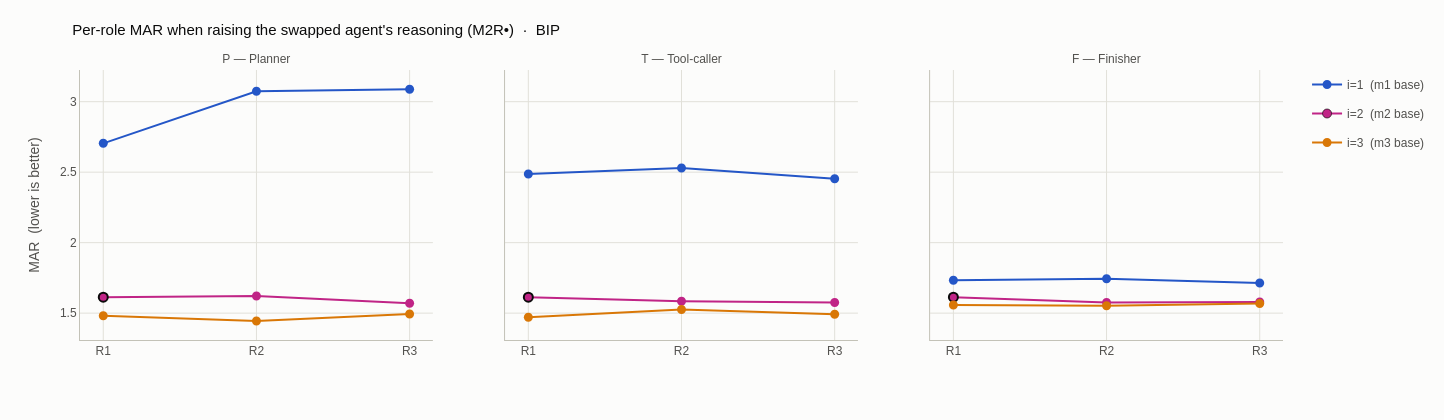

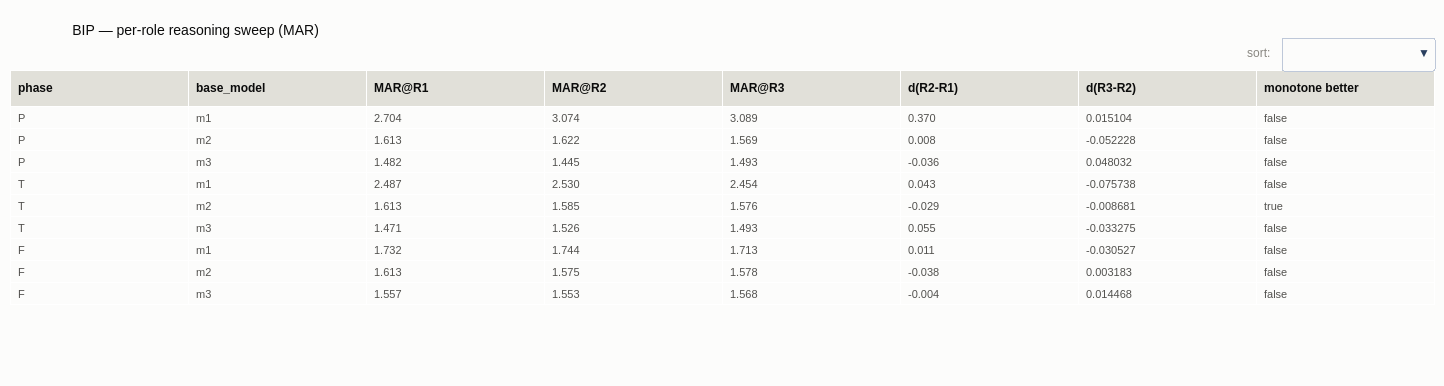

BIP: R2 beats R1 in 4/9 groups; R3 beats R2 in 5/9; R3 beats R1 in 5/9


In [33]:
save_fig(
    sweep_figure(
        "BIP", R_FAMILY, FAMILY_TICKS["R"], "MAR",
        title="Per-role MAR when raising the swapped agent's reasoning (M2R•)  ·  BIP",
    ),
    "q3_bip_per_role_reasoning_sweep_mar",
).show()
sortable_table(
    save_table(
        sweep_table("BIP", R_FAMILY, FAMILY_TICKS["R"], "MAR"),
        "q3_bip_per_role_reasoning_sweep_mar",
    ),
    title="BIP — per-role reasoning sweep (MAR)",
).show()
w = sweep_verdict("BIP", R_FAMILY, "MAR")
print(f"BIP: R2 beats R1 in {w[0]}/9 groups; R3 beats R2 in {w[1]}/9; R3 beats R1 in {w[2]}/9")

## 4. Does a higher-tier / larger model for FlexFL yield better FL accuracy?

> *Alternate phrasing:* Does assigning a role a larger-tier model improve FlexFL's FL accuracy?

**Draft interpretation of the notes.** The notes' check — is $MAR(U(m_{x+1}, R_i)) < MAR(U(m_x, R_i))$ for every $x$ — is directly computable at $R1$, where all three uniforms exist. The **uniform reading** below is the primary answer: upgrading the whole agent one tier at a time, now with paired per-bug bootstrap CIs so it mirrors Q3's uniform reasoning sweep — the two axes share the $U(M2R1)$ anchor, so their tables are directly comparable (Q5 prices that comparison). The **per-role** sweeps ($m_1 \rightarrow m_2 \rightarrow m_3$ swapped into a single role on each background; uniform anchors ring-marked; "monotone better" = MAR strictly falls with each step) remain the finer-grained secondary reading.

**Columns of the tables in this section.** MAR is the mean average rank of the fault over the benchmark's bugs — **lower is better**, so an improvement is a *negative* delta.

*Uniform MAR per tier* (one row per benchmark — the whole agent upgraded at once):

- `benchmark` — D4J or BIP.
- `MAR U(m1)` / `MAR U(m2)` / `MAR U(m3)` — MAR of the uniform config at each tier (all at R1).
- `d(m2-m1)` / `d(m3-m2)` — change per tier step; negative = the bigger model localizes better.
- `monotone better` — `True` iff MAR falls strictly at both steps, i.e. the notes' inequality holds for every $x$.

*Per-role tier sweep* (9 rows = 3 phases × 3 base tiers):

- `phase` — the single role whose model is swapped: `P` Planner, `T` Tool-caller, `F` Finisher.
- `base_model` — the tier $m_i$ every *other* role keeps.
- `MAR@m1` / `MAR@m2` / `MAR@m3` — MAR with that tier in the swapped role; the $i=2$ row starts at the uniform anchor $U(m_2)$.
- `d(m2-m1)` / `d(m3-m2)` — change per step, negative = better.
- `monotone better` — `True` iff MAR falls strictly at both steps for this (phase, base) group.

The printed line counts, out of the 9 groups, how many improve at each step — the summary that the per-row `monotone better` flags feed.

### Uniform, both benchmarks

Paired per-bug bootstrap CIs (95%) on the mean AR delta of each step: negative = the step improves accuracy; an interval clear of 0 = significant at the panel size.

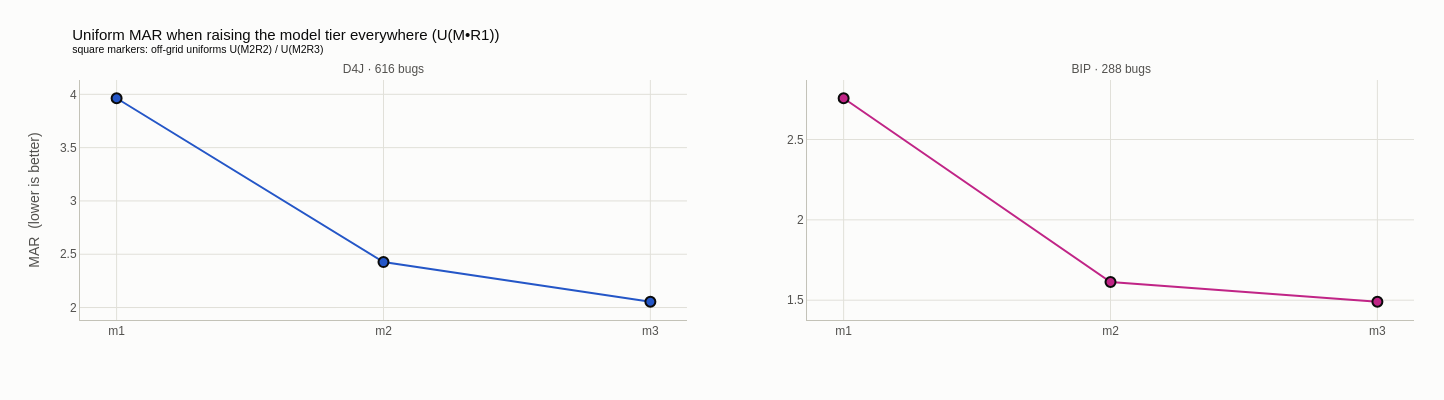

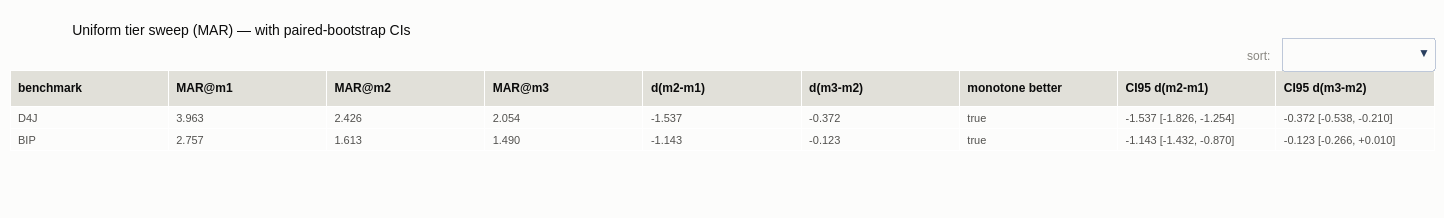

In [34]:
# Uniform tier sweep: MAR of upgrading the whole agent one tier at a time.
save_fig(
    uniform_axis_figure(
        TIER_FAMILY, FAMILY_TICKS["tier"], "MAR",
        title="Uniform MAR when raising the model tier everywhere (U(M•R1))",
    ),
    "q4_uniform_tier_sweep_mar",
).show()
sortable_table(
    save_table(
        uniform_axis_table(TIER_FAMILY, FAMILY_TICKS["tier"], "MAR", ci=True),
        "q4_uniform_tier_sweep_mar",
    ),
    title="Uniform tier sweep (MAR) — with paired-bootstrap CIs",
).show()

### Defects4J (D4J)

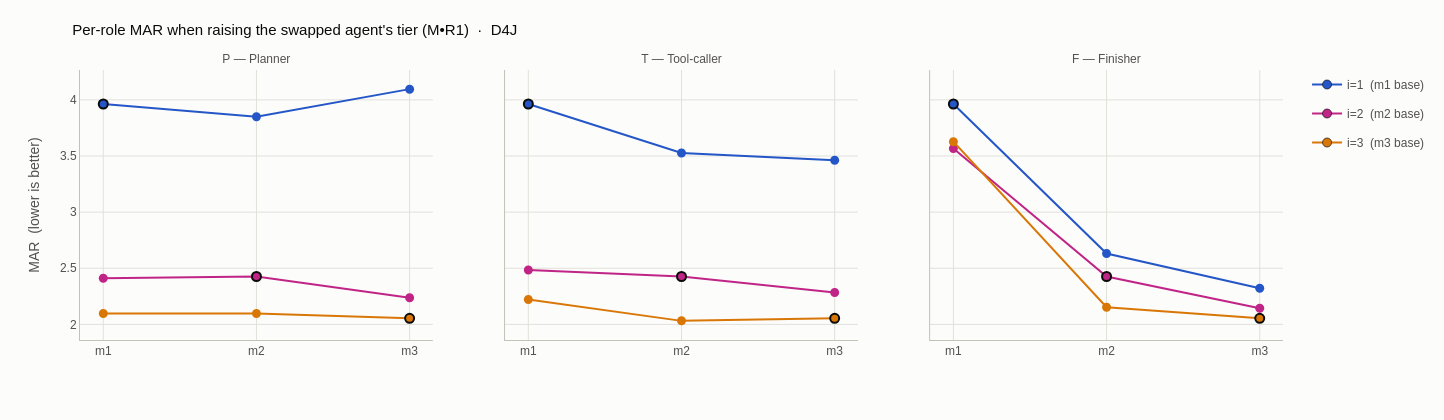

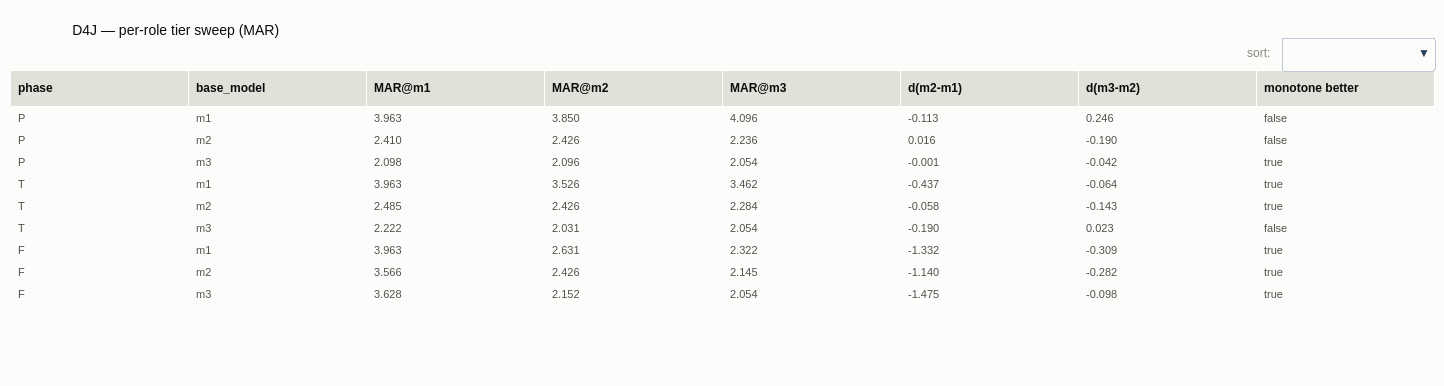

D4J: m2 beats m1 in 8/9 groups; m3 beats m2 in 7/9; m3 beats m1 in 8/9


In [35]:
save_fig(
    sweep_figure(
        "D4J", TIER_FAMILY, FAMILY_TICKS["tier"], "MAR",
        title="Per-role MAR when raising the swapped agent's tier (M•R1)  ·  D4J",
    ),
    "q4_d4j_per_role_tier_sweep_mar",
).show()
sortable_table(
    save_table(
        sweep_table("D4J", TIER_FAMILY, FAMILY_TICKS["tier"], "MAR"),
        "q4_d4j_per_role_tier_sweep_mar",
    ),
    title="D4J — per-role tier sweep (MAR)",
).show()
w = sweep_verdict("D4J", TIER_FAMILY, "MAR")
print(f"D4J: m2 beats m1 in {w[0]}/9 groups; m3 beats m2 in {w[1]}/9; m3 beats m1 in {w[2]}/9")

### BugsInPy (BIP)

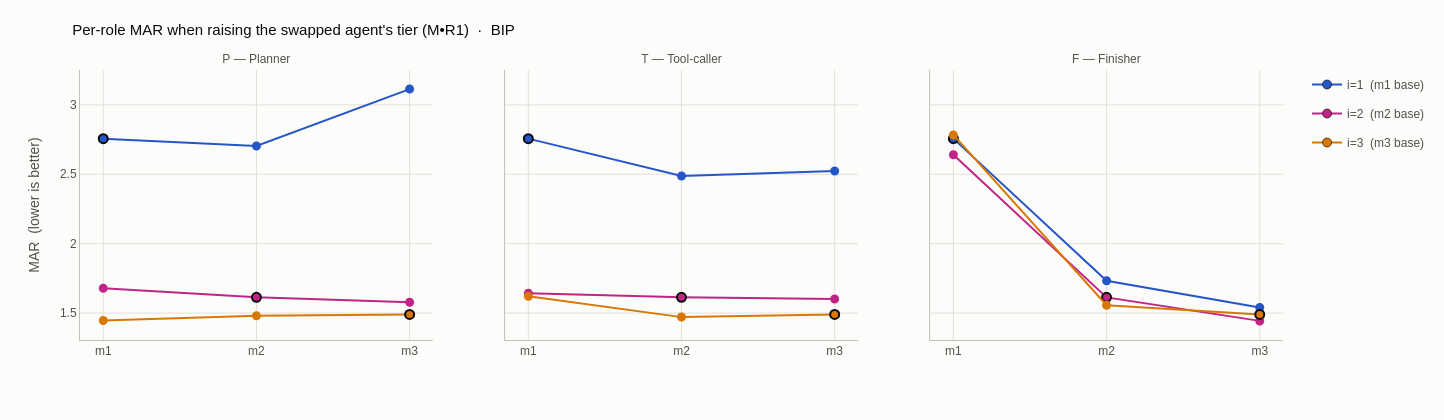

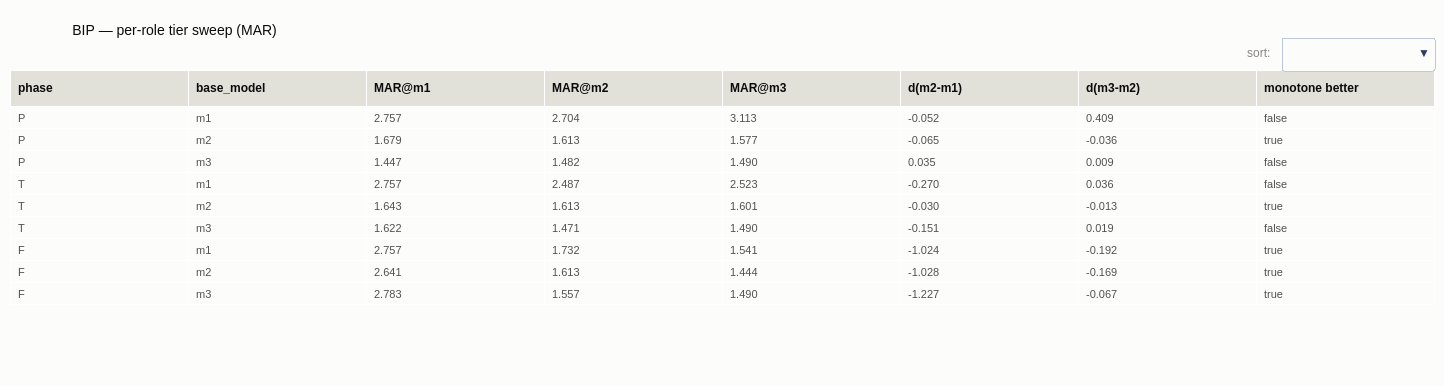

BIP: m2 beats m1 in 8/9 groups; m3 beats m2 in 5/9; m3 beats m1 in 7/9


In [36]:
save_fig(
    sweep_figure(
        "BIP", TIER_FAMILY, FAMILY_TICKS["tier"], "MAR",
        title="Per-role MAR when raising the swapped agent's tier (M•R1)  ·  BIP",
    ),
    "q4_bip_per_role_tier_sweep_mar",
).show()
sortable_table(
    save_table(
        sweep_table("BIP", TIER_FAMILY, FAMILY_TICKS["tier"], "MAR"),
        "q4_bip_per_role_tier_sweep_mar",
    ),
    title="BIP — per-role tier sweep (MAR)",
).show()
w = sweep_verdict("BIP", TIER_FAMILY, "MAR")
print(f"BIP: m2 beats m1 in {w[0]}/9 groups; m3 beats m2 in {w[1]}/9; m3 beats m1 in {w[2]}/9")

## 5. By how much does using higher reasoning effort, or a higher tier model, increase the cost of a FlexFL task?

> *Alternate phrasing:* What cost premium does one step up in reasoning effort, versus one step up in model tier, add to a FlexFL run?

**Draft interpretation of the notes — updated with the off-grid uniform runs.** The notes ask to plot $Cost(U(m_x, R_i))$ while increasing $x$ and $i$; with $U(M2R2)$ / $U(M2R3)$ now evaluated on both benchmarks, **both axes have a uniform reading**, pivoting at the shared anchor $U(M2R1)$:

- **Tier axis:** $Cost(U(M1R1)) \rightarrow Cost(U(M2R1)) \rightarrow Cost(U(M3R1))$ — upgrading the *whole* agent one tier at a time.
- **Reasoning axis:** $Cost(U(M2R1)) \rightarrow Cost(U(M2R2)) \rightarrow Cost(U(M2R3))$ — raising the *whole* agent's reasoning effort one step at a time.

The cost/MAR plane below puts the two axes head-to-head: what each extra dollar buys in accuracy along either upgrade path. The per-role multipliers (one role upgraded, the other two fixed) follow as the secondary, finer-grained reading.

**Columns of the tables in this section.** All costs are mean USD per bug; multipliers are ratios of consecutive steps, so `1.00` = a free upgrade and `2.00` = twice the price.

*Uniform cost per tier step* (one row per benchmark — the whole agent upgraded at once):

- `benchmark` — D4J or BIP.
- `U(m1) $` / `U(m2) $` / `U(m3) $` — cost of the uniform config at each tier (all at R1).
- `x(m2/m1)` / `x(m3/m2)` — the premium of one tier step; `x(m3/m1)` — the compound premium of both.

*Per-role cost multipliers* (9 rows = 3 phases × 3 base tiers, one table per family):

- `phase` — the single role whose model is swapped: `P` Planner, `T` Tool-caller, `F` Finisher.
- `base_model` — the tier $m_i$ every *other* role keeps.
- `Cost@R1/R2/R3` (reasoning family) or `Cost@m1/m2/m3` (tier family) — cost with that model in the swapped role. The $i=2$ row starts at the uniform anchor $U(m_2)$.
- `x(R2/R1)`, `x(R3/R2)` / `x(m2/m1)`, `x(m3/m2)` — the per-step premium of upgrading **one role only**.

The printed line under each pair reports the **median** per-step multiplier across the 9 groups — the headline comparison of a reasoning-effort step against a tier step.

### Uniform, both benchmarks

In [37]:
# Uniform premiums, both axes: the cost of upgrading the whole agent one step
# at a time — tier at fixed R1, reasoning at fixed tier 2 — plus the cost/MAR
# plane that shows what each dollar buys along either path.
save_fig(uniform_plane_figure(), "q5_uniform_cost_mar_plane").show()
sortable_table(
    save_table(
        uniform_axis_table(R_FAMILY, FAMILY_TICKS["R"], "Cost", ratio=True),
        "q5_uniform_reasoning_premium",
    ),
    title="Uniform reasoning premium (mean USD per bug)",
).show()
sortable_table(
    save_table(
        uniform_axis_table(TIER_FAMILY, FAMILY_TICKS["tier"], "Cost", ratio=True),
        "q5_uniform_tier_premium",
    ),
    title="Uniform tier premium (mean USD per bug)",
).show()

### Defects4J (D4J)

In [38]:
save_fig(
    sweep_figure(
        "D4J", R_FAMILY, FAMILY_TICKS["R"], "Cost",
        title="Per-role cost of raising reasoning effort (M2R•)  ·  D4J",
    ),
    "q5_d4j_per_role_reasoning_cost",
).show()
sortable_table(
    save_table(
        sweep_table("D4J", R_FAMILY, FAMILY_TICKS["R"], "Cost", ratio=True),
        "q5_d4j_reasoning_step_cost_multipliers",
    ),
    title="D4J — per-role reasoning-step cost multipliers",
).show()
save_fig(
    sweep_figure(
        "D4J", TIER_FAMILY, FAMILY_TICKS["tier"], "Cost",
        title="Per-role cost of raising the model tier (M•R1)  ·  D4J",
    ),
    "q5_d4j_per_role_tier_cost",
).show()
sortable_table(
    save_table(
        sweep_table("D4J", TIER_FAMILY, FAMILY_TICKS["tier"], "Cost", ratio=True),
        "q5_d4j_tier_step_cost_multipliers",
    ),
    title="D4J — per-role tier-step cost multipliers",
).show()

rt = sweep_table("D4J", R_FAMILY, FAMILY_TICKS["R"], "Cost", ratio=True)
tt = sweep_table("D4J", TIER_FAMILY, FAMILY_TICKS["tier"], "Cost", ratio=True)
print(
    f"D4J median per-role premium:  +1 R step x{rt['x(R2/R1)'].median():.2f}"
    f" / x{rt['x(R3/R2)'].median():.2f}   |   +1 tier step x{tt['x(m2/m1)'].median():.2f}"
    f" / x{tt['x(m3/m2)'].median():.2f}"
)

D4J median per-role premium:  +1 R step x1.02 / x1.18   |   +1 tier step x1.36 / x2.07


### BugsInPy (BIP)

In [39]:
save_fig(
    sweep_figure(
        "BIP", R_FAMILY, FAMILY_TICKS["R"], "Cost",
        title="Per-role cost of raising reasoning effort (M2R•)  ·  BIP",
    ),
    "q5_bip_per_role_reasoning_cost",
).show()
sortable_table(
    save_table(
        sweep_table("BIP", R_FAMILY, FAMILY_TICKS["R"], "Cost", ratio=True),
        "q5_bip_reasoning_step_cost_multipliers",
    ),
    title="BIP — per-role reasoning-step cost multipliers",
).show()
save_fig(
    sweep_figure(
        "BIP", TIER_FAMILY, FAMILY_TICKS["tier"], "Cost",
        title="Per-role cost of raising the model tier (M•R1)  ·  BIP",
    ),
    "q5_bip_per_role_tier_cost",
).show()
sortable_table(
    save_table(
        sweep_table("BIP", TIER_FAMILY, FAMILY_TICKS["tier"], "Cost", ratio=True),
        "q5_bip_tier_step_cost_multipliers",
    ),
    title="BIP — per-role tier-step cost multipliers",
).show()

rt = sweep_table("BIP", R_FAMILY, FAMILY_TICKS["R"], "Cost", ratio=True)
tt = sweep_table("BIP", TIER_FAMILY, FAMILY_TICKS["tier"], "Cost", ratio=True)
print(
    f"BIP median per-role premium:  +1 R step x{rt['x(R2/R1)'].median():.2f}"
    f" / x{rt['x(R3/R2)'].median():.2f}   |   +1 tier step x{tt['x(m2/m1)'].median():.2f}"
    f" / x{tt['x(m3/m2)'].median():.2f}"
)

BIP median per-role premium:  +1 R step x1.02 / x1.17   |   +1 tier step x1.35 / x2.03


## 6. Does assigning different LLM models yield a better cost-performance trade-off in multi-step FL tasks compared to a single, homogeneous agent?

> *Alternate phrasing:* Does mixing models across roles reach a better cost-accuracy trade-off in multi-step FL than the best single homogeneous assignment?

**Draft interpretation of the notes.** All 39 configs in cost/MAR space, measured against what *homogeneous* agents achieve:

- **Uniform frontier** (solid) — the piecewise-linear line through the uniform configs in cost order (D4J: 5 of them, incl. the two off-grid ones below; BIP: 3). Points below/left of it get a better cost-accuracy trade-off than any uniform blend.
- **Significance frontier** (dashed) — the same line with every vertex scaled by $(1-\alpha)$ toward the origin ($\alpha$ = `ALPHA_SIG` in the helpers cell, default 5%). A mixed config **crosses** it when it strictly dominates some point of the shrunken line — simultaneously cheaper *and* more accurate than the frontier even after conceding an $\alpha$ relative margin on both axes. This implements the notes' $\epsilon$-condition with $\epsilon_C$ and $\epsilon_{MAR}$ tied to a single relative margin instead of two hand-picked absolutes.

The two lines split the mixed configs into the plot's three marker groups, mirrored by the table's `region` column:

- ⭐ **crosses α-frontier** — beats every uniform blend by more than the $\alpha$ margin: the configs the question is answered with.
- 🔹 **between frontiers** (small diamonds) — beats the uniform frontier, but by less than $\alpha$: real but marginal improvements.
- ▪ **above frontier** (faint dots) — some uniform blend matches or beats them.

The table ranks every **mixed** config (uniforms define the frontier and are omitted) by how decisively it crosses:

- `Config` / `MAR` / `Cost` — the configuration's own values (`Cost` is raw USD per bug).
- `MAR/ref` / `Cost/ref` — own value over the value at the *nearest position* on the (unshrunk) frontier, found in min–max normalized cost/MAR space; `< 1` = more accurate / cheaper than the frontier there. Read them together: e.g. `0.96 / 0.30` = 96% of the frontier's MAR at 30% of its cost.
- `dist` — signed Euclidean distance to the unshrunk frontier in the normalized space (negative = the better side); the continuous companion to the crossing test.
- `alpha_max` — **the significance margin**: the largest $\alpha$ whose shrunken frontier the config still crosses (`-` = never crosses even the unshrunk line). This is the column to read the verdict off — how far the bar could be raised before the config stops clearing it.
- `region` — the marker group above (`crosses` / `between` / `above`); `crosses` $\iff$ `alpha_max` $\geq$ `ALPHA_SIG`.

**Per-bug significance:** deferred — the paired bootstrap (`q6_bootstrap`) is kept in the helpers for a later pass once the config pairs worth testing are settled; `alpha_max` is a practical-margin criterion, not a statistical one.

**Extra uniforms.** The 39-config grid holds uniforms at minimal reasoning only, but both benchmarks *did* run $U(M2R2)$ and $U(M2R3)$ (`M2R2-M2R2-M2R2` / `M2R3-M2R3-M2R3`) — D4J with the original sweep, BIP in the 2026-08-24 batch; they were dropped at the aggregation step, not missing. Since the frontier question is about what a *homogeneous* agent can achieve at a given price, leaving them out understates the uniform frontier — so they are read straight from `evaluation/<BM>/flexfl.csv`, restricted to each benchmark's own full-sweep panel, and treated as **uniform points** (square symbol, own legend entry). Coverage on the panels: D4J 616 / 616 for $U(M2R2)$ and 615 / 616 for $U(M2R3)$; BIP 288 / 288 for both — so their MAR is comparable to the grid's without re-cutting the panels. Q3–Q5's uniform readings consume the same points via the §0 helpers.

### Defects4J (D4J)

In [40]:
save_fig(q6_frontier_figure("D4J"), "q6_d4j_frontier").show()

sortable_table(
    save_table(q6_table("D4J").round(4), "q6_d4j_mixed_vs_uniform_frontier"),
    title=f"D4J — mixed configs vs the uniform frontier (ranked by alpha_max; crosses at ≥ {ALPHA_SIG:.0%})",
).show()

# Per-pair paired bootstrap (q6_bootstrap) deferred until the config pairs
# worth testing are settled.

### BugsInPy (BIP)

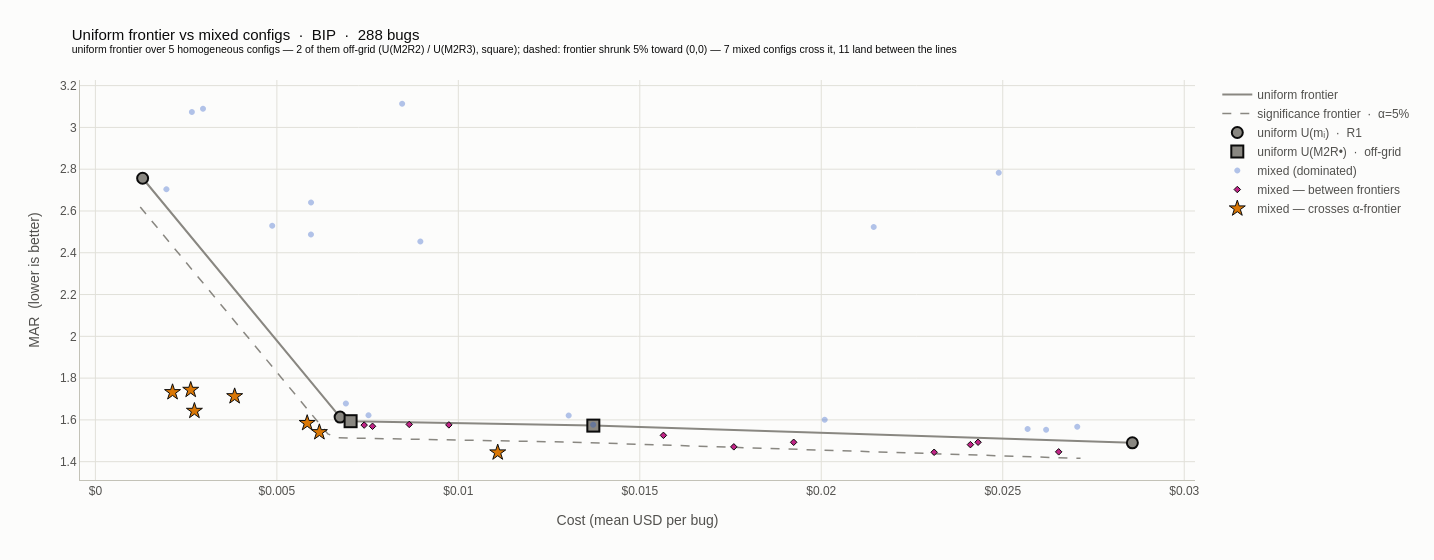

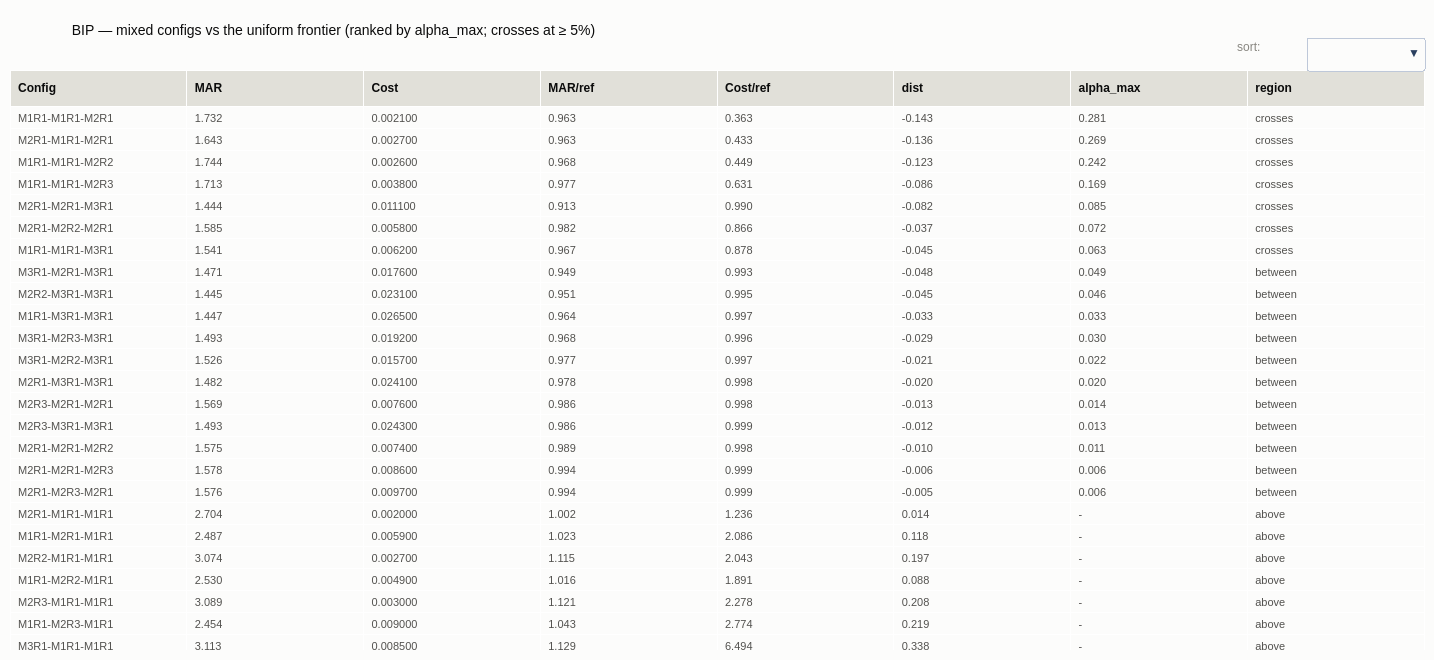

In [41]:
# Same code path as D4J; since the 2026-08-24 batch EXTRA_UNIFORMS["BIP"] also
# holds U(M2R2) / U(M2R3), so BIP's frontier is a 5-uniform line too.
save_fig(q6_frontier_figure("BIP"), "q6_bip_frontier").show()

sortable_table(
    save_table(q6_table("BIP").round(4), "q6_bip_mixed_vs_uniform_frontier"),
    title=f"BIP — mixed configs vs the uniform frontier (ranked by alpha_max; crosses at ≥ {ALPHA_SIG:.0%})",
).show()